## Imports

In [5]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio import features
import numpy as np
import matplotlib.pyplot as plt
from pystac_client import Client
from odc.stac import load
import requests
import zipfile
import io
import os
from shapely import geometry
from shapely.geometry import box
from sklearn.model_selection import train_test_split
import seaborn as sns
import time
import math
import ast
from PIL import Image
from io import BytesIO

In [6]:
import ee
import geemap

ee.Authenticate(force=True, auth_mode='localhost')


Successfully saved authorization token.


In [7]:
project_id = "ee-abdullahr-solar"
ee.Initialize(project=project_id)

## Dataset Preparation

In [3]:
gpkg_path = "global_pv_facility_inventory.gpkg" 
solar_gdf = gpd.read_file(gpkg_path)


🌍 GLOBAL SOLAR DATASET (>=2019, >=100m²)
Total Sites Remaining: 63,939
Total Area Covered:    9,837.85 km²
Most Represented:      China



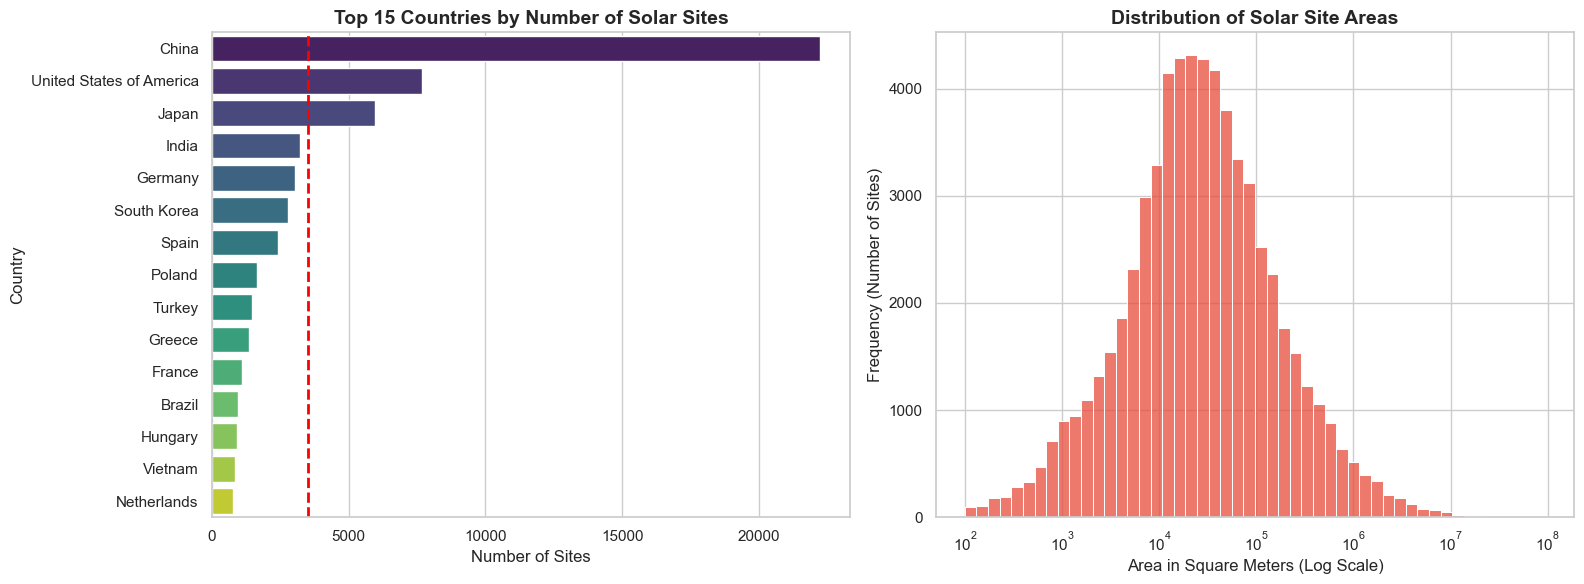

In [52]:
# ==============================================================================
# 1. APPLY FILTERS
# ==============================================================================
# Since 'year' is already an int64 and 'area_m2' is already calculated, 
# we can filter the entire dataset in two extremely fast, simple lines.

filtered_gdf = solar_gdf[
    (solar_gdf['year'] >= 2019) & 
    (solar_gdf['area_m2'] >= 100.0)
].copy()

# ==============================================================================
# 2. GENERAL STATISTICS
# ==============================================================================
total_sites = len(filtered_gdf)
total_area_km2 = filtered_gdf['area_m2'].sum() / 1e6 # Convert m^2 to km^2
top_country = filtered_gdf['country'].value_counts().idxmax() 

print("\n" + "="*40)
print("🌍 GLOBAL SOLAR DATASET (>=2019, >=100m²)")
print("="*40)
print(f"Total Sites Remaining: {total_sites:,}")
print(f"Total Area Covered:    {total_area_km2:,.2f} km²")
print(f"Most Represented:      {top_country}")
print("="*40 + "\n")

# ==============================================================================
# 3. VISUALIZATIONS
# ==============================================================================
# Set a clean visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: Top 15 Countries ---
top_countries = filtered_gdf['country'].value_counts().head(15)
sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    ax=axes[0], 
    palette="viridis",
    hue=top_countries.index, # Added hue to avoid seaborn warnings
    legend=False
)

axes[0].axvline(3500, color='red', linestyle='dashed', linewidth=2)
axes[0].set_title("Top 15 Countries by Number of Solar Sites", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Sites", fontsize=12)
axes[0].set_ylabel("Country", fontsize=12)

# --- Plot B: Area Distribution ---
# Using a log scale because solar site areas have a massive right-skew
# (lots of small 100m^2 sites, a few massive 10,000,000m^2 utility farms)
sns.histplot(
    data=filtered_gdf, 
    x='area_m2', 
    bins=50, 
    log_scale=True, 
    ax=axes[1], 
    color="#e74c3c"
)

axes[1].set_title("Distribution of Solar Site Areas", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Area in Square Meters (Log Scale)", fontsize=12)
axes[1].set_ylabel("Frequency (Number of Sites)", fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# Assuming your filtered_gdf is what we are using for the ML pipeline
train_gdf = filtered_gdf.copy()

# 1. The Resume Flag: Tracks if the image chip was successfully downloaded
train_gdf['exported'] = False

# 2. The Linker: Stores the exact file path (e.g., "chip_140945_2023.npy") 
# so the PyTorch Dataset class knows exactly what to load
train_gdf['export_filename'] = None

# 3. The Temporal Target: Maps to the 'year' column so we know which 
# historical satellite mosaic to pull.
train_gdf['target_year'] = train_gdf['year']

# 4. The Footprint: Initialized as None for now. 
# Tomorrow, we will calculate the 128x128 pixel Shapely Polygons and store them here!
train_gdf['ml_bbox'] = None

train_gdf['dataset_split'] = 'unassigned'  # 'train', 'val', or 'test'

# Let's verify the new pipeline schema
print("Training Pipeline Schema Ready:")
print(train_gdf[['PV_ID', 'target_year', 'exported', 'export_filename', 'ml_bbox']].head())

Training Pipeline Schema Ready:
   PV_ID  target_year  exported export_filename ml_bbox
0      1         2020     False            None    None
2      3         2021     False            None    None
3      4         2023     False            None    None
4      5         2024     False            None    None
5      6         2022     False            None    None


In [11]:
print(f"Starting total sites: {len(train_gdf):,}")

# 1. Shuffle the entire dataset to ensure random sampling within countries
# (random_state=42 ensures you get the exact same split if you run this twice)
shuffled_gdf = train_gdf.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Group by country and take up to 3500 random sites from each
CAP = 3500
base_train_gdf = shuffled_gdf.groupby('country').head(CAP).copy()

# 3. Create the overflow dataset containing everything left over
# We identify the leftovers by dropping the indices that were used in the base dataset
overflow_gdf = shuffled_gdf.drop(base_train_gdf.index).copy()

# ==============================================================================
# VERIFICATION
# ==============================================================================
print("\n" + "="*40)
print("🌍 DATASET SPLIT RESULTS")
print("="*40)
print(f"Base Training Dataset: {len(base_train_gdf):,} sites")
print(f"Overflow Dataset:      {len(overflow_gdf):,} sites")
print("="*40 + "\n")

# Let's look at what happened to the top 5 countries
print("Top 5 Countries in Base Dataset:")
print(base_train_gdf['country'].value_counts().head(10))

print("\nTop 5 Countries in Overflow Dataset:")
print(overflow_gdf['country'].value_counts().head(5))

Starting total sites: 63,939

🌍 DATASET SPLIT RESULTS
Base Training Dataset: 38,599 sites
Overflow Dataset:      25,340 sites

Top 5 Countries in Base Dataset:
country
China                       3500
Japan                       3500
United States of America    3500
India                       3232
Germany                     3023
South Korea                 2789
Spain                       2402
Poland                      1661
Turkey                      1481
Greece                      1349
Name: count, dtype: int64

Top 5 Countries in Overflow Dataset:
country
China                       18719
United States of America     4168
Japan                        2453
Name: count, dtype: int64


In [23]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from tqdm import tqdm

# ==============================================================================
# 1. SETUP THE EXCLUSION ZONE
# ==============================================================================
print("Building the Global Solar Exclusion Zone...")
# We use the FULL dataset (solar_gdf) to ensure we avoid ALL known sites, 
# not just the ones in our training split.
solar_gdf_meters = solar_gdf.to_crs("EPSG:6933")

# Buffer every known site by 3,000 meters (approx 300 pixels) to be totally safe
# unary_union merges them all into one massive global "Do Not Touch" multipolygon
exclusion_zone = solar_gdf_meters.geometry.buffer(5000).unary_union

# 2. LOAD WORLD BOUNDARIES (Direct from Web)
print("Fetching world map boundaries...")
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)
world = world.to_crs("EPSG:6933")

# Note: The 'name' column in this GeoJSON is called 'name', 
# so the rest of the script (world.name == country_name) will still work perfectly!

# ==============================================================================
# 3. GENERATE PROPORTIONAL NEGATIVE CHIPS (512x512)
# ==============================================================================
# Get our target 1:1 ratio from the base training set
target_counts = base_train_gdf['country'].value_counts()

negative_records = []
# 512 pixels * 10m/pixel = 5120 meters. Radius from center is 2560m.
HALF_BOX_METERS = 2560 

print(f"Generating True Negative 512x512 Bounding Boxes...")
for country_name, required_count in tqdm(target_counts.items()):
    
    # Try to find the country in the world map
    # (Note: Name matching can sometimes be tricky between datasets, e.g., 'USA' vs 'United States')
    country_match = world[world.name == country_name]
    
    if country_match.empty:
        # Fallback: If names don't match, just use the bounding box of the solar sites in that country
        country_geom = solar_gdf_meters[solar_gdf_meters['country'] == country_name].geometry.unary_union.convex_hull
    else:
        country_geom = country_match.geometry.unary_union
        
    # Find bounding box of the country to optimize random point generation
    minx, miny, maxx, maxy = country_geom.bounds
    
    valid_points_found = 0
    attempts = 0
    max_attempts = required_count * 50 # Prevent infinite loops in tiny countries
    
    while valid_points_found < required_count and attempts < max_attempts:
        attempts += 1
        
        # 1. Generate a random point within the country's bounds
        random_x = np.random.uniform(minx, maxx)
        random_y = np.random.uniform(miny, maxy)
        random_point = Point(random_x, random_y)
        
        # 2. Check if it's actually inside the country borders AND NOT in the exclusion zone
        if country_geom.contains(random_point) and not exclusion_zone.contains(random_point):
            
            # 3. Build the 5120m x 5120m bounding box around the point
            neg_bbox = box(
                random_x - HALF_BOX_METERS, 
                random_y - HALF_BOX_METERS, 
                random_x + HALF_BOX_METERS, 
                random_y + HALF_BOX_METERS
            )
            
            negative_records.append({
                'PV_ID': f"NEG_{country_name[:3].upper()}_{valid_points_found}",
                'country': country_name,
                'target_year': 2023, # You can randomize this later if needed
                'exported': False,
                'export_filename': None,
                'dataset_split': 'unassigned',
                'geometry': neg_bbox # We store the BOX, not the point!
            })
            valid_points_found += 1

# ==============================================================================
# 4. FINALIZE THE NEGATIVE GEODATAFRAME
# ==============================================================================
negative_gdf = gpd.GeoDataFrame(negative_records, crs="EPSG:6933")

# Project back to standard GPS coordinates for the API
negative_gdf = negative_gdf.to_crs("EPSG:4326")

print("\n" + "="*40)
print("✅ TRUE NEGATIVE DATASET GENERATED")
print("="*40)
print(f"Total Negative 512x512 Chips: {len(negative_gdf):,}")
print("="*40 + "\n")

Building the Global Solar Exclusion Zone...


/tmp/ipykernel_64486/2077122079.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  exclusion_zone = solar_gdf_meters.geometry.buffer(5000).unary_union


Fetching world map boundaries...
Generating True Negative 512x512 Bounding Boxes...


0it [00:00, ?it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
1it [00:00,  3.40it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
2it [00:00,  2.10it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
3it [00:01,  2.42it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
4it [00:01,  2.82it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' me


✅ TRUE NEGATIVE DATASET GENERATED
Total Negative 512x512 Chips: 38,564



/tmp/ipykernel_64486/1072795844.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  exclusion_patch = mpatches.Patch(


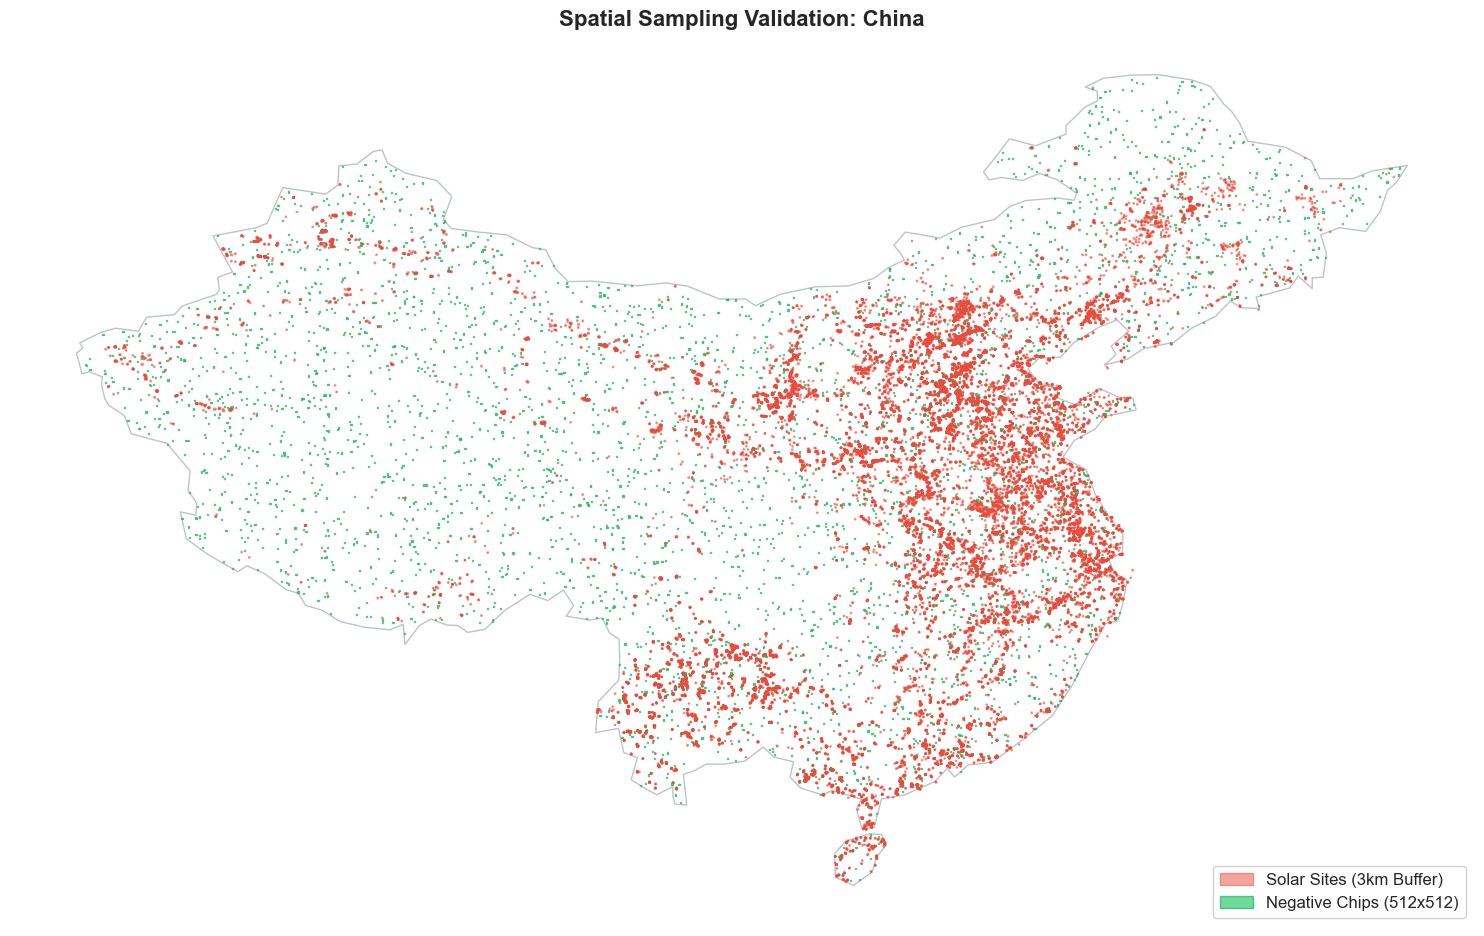

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

# 1. Filter for the target country
target_country = "China"
country_boundary = world[world.name == target_country].to_crs("EPSG:6933")

# 2. Get Solar Sites in China + Buffer them by 3000m
china_solar = solar_gdf[solar_gdf['country'] == target_country].to_crs("EPSG:6933")
china_exclusion_zones = china_solar.geometry.buffer(3000)

# 3. Get our new Negative Bounding Boxes for China
china_negatives = negative_gdf[negative_gdf['country'] == target_country].to_crs("EPSG:6933")

# 4. Plotting
fig, ax = plt.subplots(figsize=(15, 12))

# Plot Country Background
country_boundary.plot(ax=ax, color='none', edgecolor='#bdc3c7', linewidth=1)

# Plot the Geometries (no need for label= here)
china_exclusion_zones.plot(ax=ax, color='#e74c3c', alpha=0.5, edgecolor='#e74c3c')
china_negatives.plot(ax=ax, color='#2ecc71', alpha=0.7, edgecolor='#27ae60')

# =========================================================
# THE FIX: Custom Legend Handles
# =========================================================
exclusion_patch = mpatches.Patch(
    color='#e74c3c', edgecolor='#e74c3c', alpha=0.5, 
    label='Solar Sites (3km Buffer)'
)
negative_patch = mpatches.Patch(
    facecolor='#2ecc71', edgecolor='#27ae60', alpha=0.7, 
    label='Negative Chips (512x512)'
)

ax.set_title(f"Spatial Sampling Validation: {target_country}", fontsize=16, fontweight='bold')
ax.legend(handles=[exclusion_patch, negative_patch], loc='lower right', framealpha=0.9, fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()

In [49]:
import numpy as np

print("Finalizing True Negative Dataset...")

# Work on a copy to avoid Pandas warnings
df_neg = negative_gdf.copy()

# ==============================================================================
# 1. RANDOMIZED TEMPORAL LOGIC
# ==============================================================================
# np.random.randint is exclusive on the high end, so 2023 gives us 2017-2022
df_neg['target_year'] = np.random.randint(2017, 2023, size=len(df_neg))

# ==============================================================================
# 2. NAMING CONVENTION
# ==============================================================================
df_neg['export_filename'] = (
    df_neg['PV_ID'].astype(str) + "_" + 
    df_neg['target_year'].astype(str) + ".tif"
)

# ==============================================================================
# 3. AREA & GEOGRAPHIC METADATA
# ==============================================================================
# No solar panels here!
df_neg['area_m2'] = 0.0

# Ensure we are in standard GPS coordinates before calculating centroids
df_neg = df_neg.to_crs("EPSG:4326")

# Calculate the exact center of the 512x512 box
centroids = df_neg.geometry.centroid
df_neg['latitude'] = centroids.y
df_neg['longitude'] = centroids.x

# ==============================================================================
# 4. SCHEMA ALIGNMENT (Crucial for the Export Script)
# ==============================================================================
# Your export script will be looking for a column named 'ml_bbox'. 
# Since the 'geometry' of the negative dataset IS the bounding box, 
# we simply copy it over so both dataframes have the exact same structure!
df_neg['ml_bbox'] = df_neg.geometry

# Save the finalized dataframe back to your main variable
negative_gdf = df_neg

# ==============================================================================
# VERIFICATION
# ==============================================================================
print("\n✅ NEGATIVE DATASET FINALIZED.")
print(f"Total Rows: {len(negative_gdf):,}")
print("\nSample Output:")
print(negative_gdf[['PV_ID', 'country', 'target_year', 'export_filename', 'latitude', 'longitude']].head())

Finalizing True Negative Dataset...

✅ NEGATIVE DATASET FINALIZED.
Total Rows: 38,564

Sample Output:
       PV_ID country  target_year     export_filename   latitude   longitude
0  NEG_CHI_0   China         2022  NEG_CHI_0_2022.tif  41.102360   96.743575
1  NEG_CHI_1   China         2019  NEG_CHI_1_2019.tif  23.412427  109.621379
2  NEG_CHI_2   China         2018  NEG_CHI_2_2018.tif  35.779735   91.880557
3  NEG_CHI_3   China         2017  NEG_CHI_3_2017.tif  36.260614  110.043062
4  NEG_CHI_4   China         2018  NEG_CHI_4_2018.tif  50.901524  122.076791


/tmp/ipykernel_64486/3260320207.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df_neg.geometry.centroid


In [26]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

def finalize_pipeline_dataset(gdf):
    """Applies target year, export filename, and dynamic ml_bbox generation."""
    # Work on a copy to avoid Pandas warnings
    df = gdf.copy()
    
    # ==============================================================================
    # 1. TEMPORAL LOGIC (Target Year)
    # ==============================================================================
    # Subtract 2 years to get pre-construction imagery
    df['target_year'] = df['year'] - 2
    
    # Sanity Check: Floor it at 2017 (the start of the AlphaEarth archive)
    df['target_year'] = df['target_year'].clip(lower=2017)
    
    # ==============================================================================
    # 2. NAMING CONVENTION (Export Filename)
    # ==============================================================================
    # Replace spaces in country names with underscores so file paths don't break
    clean_country = df['country'].str.replace(' ', '_')
    
    df['export_filename'] = (
        df['PV_ID'].astype(str) + "_" + 
        clean_country + "_" + 
        df['target_year'].astype(str) + ".tif"
    )
    
    # ==============================================================================
    # 3. SPATIAL LOGIC (ml_bbox)
    # ==============================================================================
    # Project to a metric Equal-Area CRS (EPSG:6933) to do perfect 3000m math
    gdf_meters = df.to_crs("EPSG:6933")
    
    # Extract the strict bounding box limits for every solar site
    # This returns a dataframe with columns: minx, miny, maxx, maxy
    bounds = gdf_meters.geometry.bounds
    
    # Expand the bounds by 3000 meters in all cardinal directions
    # A 100m site becomes 6100m. A 500m site becomes 6500m.
    expanded_boxes = bounds.apply(
        lambda row: box(row['minx'] - 3000, 
                        row['miny'] - 3000, 
                        row['maxx'] + 3000, 
                        row['maxy'] + 3000), 
        axis=1
    )
    
    # Convert those new boxes back into a GeoSeries
    expanded_gdf = gpd.GeoDataFrame(geometry=expanded_boxes, crs="EPSG:6933")
    
    # Project back to standard GPS coordinates (EPSG:4326) for the Earth Engine API
    df['ml_bbox'] = expanded_gdf.to_crs("EPSG:4326").geometry
    
    return df

# ==============================================================================
# EXECUTION
# ==============================================================================
print("Finalizing Base Training Dataset...")
base_train_gdf = finalize_pipeline_dataset(base_train_gdf)

print("Finalizing Overflow Dataset...")
overflow_gdf = finalize_pipeline_dataset(overflow_gdf)

print("\n" + "="*50)
print("✅ PREPROCESSING COMPLETE. READY FOR DOWNLOAD.")
print("="*50)

# Print a sample to verify everything looks right
print("\nSample Output (Base Train):")
print(base_train_gdf[['PV_ID', 'year', 'target_year', 'export_filename', 'ml_bbox']].head(3))

Finalizing Base Training Dataset...
Finalizing Overflow Dataset...

✅ PREPROCESSING COMPLETE. READY FOR DOWNLOAD.

Sample Output (Base Train):
   PV_ID  year  target_year       export_filename  \
0  41621  2023         2021  41621_China_2021.tif   
1  36931  2019         2017  36931_China_2017.tif   
2  15628  2020         2018  15628_Japan_2018.tif   

                                             ml_bbox  
0  POLYGON ((116.82672 36.7867, 116.82672 36.8470...  
1  POLYGON ((115.27506 40.46989, 115.27506 40.533...  
2  POLYGON ((131.29424 31.85473, 131.29424 31.910...  


In [33]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd
import numpy as np

def finalize_pipeline_dataset(gdf):
    """Applies target year, export filename, and dynamic ml_bbox generation."""
    df = gdf.copy()
    
    # ==============================================================================
    # 1. TEMPORAL & NAMING LOGIC
    # ==============================================================================
    df['target_year'] = df['year'] - 2
    df['target_year'] = df['target_year'].clip(lower=2017)
    
    clean_country = df['country'].str.replace(' ', '_')
    df['export_filename'] = (
        df['PV_ID'].astype(str) + "_" + 
        clean_country + "_" + 
        df['target_year'].astype(str) + ".tif"
    )
    
    # ==============================================================================
    # 2. SPATIAL LOGIC (The Geographic Math Fix)
    # ==============================================================================
    # We work strictly in Lat/Lon (EPSG:4326) to ensure the box is never tilted.
    bounds = df.geometry.bounds
    
    # 1 degree of latitude is ~111.32 km anywhere on Earth
    LAT_DEG_IN_METERS = 111320.0
    lat_pad = 3000.0 / LAT_DEG_IN_METERS
    
    # Calculate the center latitude for each site to dynamically scale longitude
    center_lats = np.radians((bounds['miny'] + bounds['maxy']) / 2.0)
    lon_pad = 3000.0 / (LAT_DEG_IN_METERS * np.cos(center_lats))
    
    # Vectorized bounding box generation
    expanded_boxes = [
        box(minx - lon, miny - lat_pad, maxx + lon, maxy + lat_pad)
        for minx, miny, maxx, maxy, lon in zip(
            bounds['minx'], bounds['miny'], bounds['maxx'], bounds['maxy'], lon_pad
        )
    ]
    
    # Save perfectly un-tilted, distance-accurate Lat/Lon boxes!
    df['ml_bbox'] = gpd.GeoSeries(expanded_boxes, index=df.index, crs="EPSG:4326")
    
    return df

# ==============================================================================
# EXECUTE THE FIX
# ==============================================================================
print("Re-calculating Base Training Dataset with Trigonometric Padding...")
base_train_gdf = finalize_pipeline_dataset(base_train_gdf)

print("Re-calculating Overflow Dataset...")
overflow_gdf = finalize_pipeline_dataset(overflow_gdf)

print("✅ FIXED AND READY!")

Re-calculating Base Training Dataset with Trigonometric Padding...
Re-calculating Overflow Dataset...
✅ FIXED AND READY!


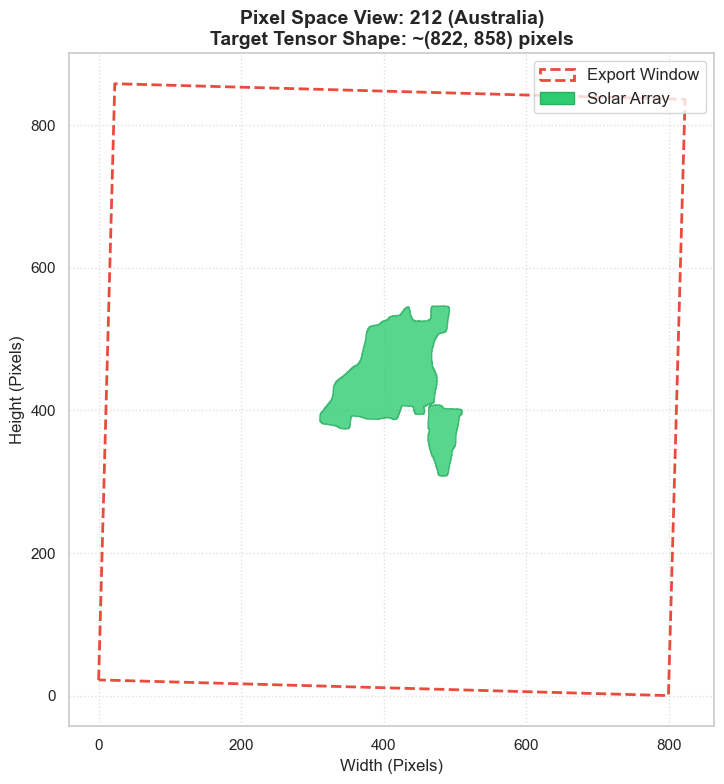

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.affinity import translate, scale

# ==============================================================================
# 1. SELECT A RANDOM SITE
# ==============================================================================
random_site = base_train_gdf.sample(1).iloc[0]

site_id = random_site['PV_ID']
country = random_site['country']
target_year = random_site['target_year']

# Convert to GeoSeries (raw lat/lon)
solar_latlon = gpd.GeoSeries([random_site['geometry']], crs="EPSG:4326")
box_latlon = gpd.GeoSeries([random_site['ml_bbox']], crs="EPSG:4326")

# ==============================================================================
# 2. EXTRACT AND PROJECT GEOMETRIES (THE UTM FIX)
# ==============================================================================
# Automatically calculate the perfect, distortion-free Local UTM zone
local_utm_crs = solar_latlon.estimate_utm_crs()

# Project to the local metric zone
solar_meters = solar_latlon.to_crs(local_utm_crs)
box_meters = box_latlon.to_crs(local_utm_crs)

# ==============================================================================
# 3. CONVERT TO PIXEL SPACE (10m = 1 Pixel, Start at 0,0)
# ==============================================================================
PIXEL_RES = 10.0

# Find the bottom-left corner of our ml_bbox in meters
minx, miny, maxx, maxy = box_meters.geometry.iloc[0].bounds

def convert_to_pixels(geom):
    # Shift the bottom-left corner to (0, 0)
    shifted = translate(geom, xoff=-minx, yoff=-miny)
    # Divide by 10 to convert meters to pixels
    pixel_geom = scale(shifted, xfact=1/PIXEL_RES, yfact=1/PIXEL_RES, origin=(0,0))
    return pixel_geom

# Apply the math to get our final pixel geometries
solar_pixels = solar_meters.apply(convert_to_pixels)
box_pixels = box_meters.apply(convert_to_pixels)

# ==============================================================================
# 4. VISUALIZE IN PIXEL SPACE
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the ML Bounding Box
box_pixels.plot(
    ax=ax, facecolor='none', edgecolor='#e74c3c', 
    linewidth=2, linestyle='--'
)

# Plot the Solar Array
solar_pixels.plot(
    ax=ax, facecolor='#2ecc71', edgecolor='#27ae60', alpha=0.8
)

# Formatting (dynamically grab the max width/height of the new pixel box)
max_w = int(box_pixels.geometry.iloc[0].bounds[2])
max_h = int(box_pixels.geometry.iloc[0].bounds[3])

ax.set_title(
    f"Pixel Space View: {site_id} ({country})\n"
    f"Target Tensor Shape: ~({max_w}, {max_h}) pixels", 
    fontsize=14, fontweight='bold'
)

box_patch = mpatches.Patch(facecolor='none', edgecolor='#e74c3c', linewidth=2, linestyle='--', label='Export Window')
solar_patch = mpatches.Patch(facecolor='#2ecc71', edgecolor='#27ae60', label='Solar Array')
ax.legend(handles=[box_patch, solar_patch], loc='upper right', fontsize=12)

ax.set_xlabel("Width (Pixels)", fontsize=12)
ax.set_ylabel("Height (Pixels)", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [51]:
import os

# Define your master file name
output_file = "global_solar_ml_pipeline.gpkg"
print(f"Saving datasets to {output_file}...")

def prep_for_gpkg(gdf):
    """Converts secondary geometries to text strings for safe saving."""
    df = gdf.copy()
    # Convert the bounding box geometry into a Well-Known Text (WKT) string
    if 'ml_bbox' in df.columns:
        df['ml_bbox'] = df['ml_bbox'].to_wkt()
    return df

# 1. Save the Base Training Set
prep_for_gpkg(base_train_gdf).to_file(
    output_file, 
    layer="base_train", 
    driver="GPKG"
)
print("✅ Saved base_train layer")

# 2. Save the Overflow Set
prep_for_gpkg(overflow_gdf).to_file(
    output_file, 
    layer="overflow", 
    driver="GPKG"
)
print("✅ Saved overflow layer")

# 3. Save the Negative Set
prep_for_gpkg(negative_gdf).to_file(
    output_file, 
    layer="negative", 
    driver="GPKG"
)
print("✅ Saved negative layer")

print("\nAll datasets successfully packed into a single GeoPackage!")

Saving datasets to global_solar_ml_pipeline.gpkg...
✅ Saved base_train layer
✅ Saved overflow layer
✅ Saved negative layer

All datasets successfully packed into a single GeoPackage!


## Dataset Clustering

In [8]:
# Define the file path
gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading datasets from GeoPackage...")

# 1. Load the layers
base_train_gdf = gpd.read_file(gpkg_file, layer="base_train")
overflow_gdf = gpd.read_file(gpkg_file, layer="overflow")
negative_gdf = gpd.read_file(gpkg_file, layer="negative")

# 2. Convert the ml_bbox text strings back into active Polygon geometries
base_train_gdf['ml_bbox'] = gpd.GeoSeries.from_wkt(base_train_gdf['ml_bbox'])
overflow_gdf['ml_bbox'] = gpd.GeoSeries.from_wkt(overflow_gdf['ml_bbox'])
negative_gdf['ml_bbox'] = gpd.GeoSeries.from_wkt(negative_gdf['ml_bbox'])

# 3. Print the summaries
print("\n" + "="*35)
print("📊 DATASET COUNTS")
print("="*35)
print(f"Base Train: {len(base_train_gdf):,} sites")
print(f"Overflow:   {len(overflow_gdf):,} sites")
print(f"Negative:   {len(negative_gdf):,} sites")
print("-" * 30)
print(f"Total:      {len(base_train_gdf) + len(overflow_gdf) + len(negative_gdf):,} sites")

print("\n" + "="*35)
print("📋 TRAINING DATA COLUMN STRUCTURE")
print("="*35)
print(base_train_gdf.dtypes)

Loading datasets from GeoPackage...

📊 DATASET COUNTS
Base Train: 38,599 sites
Overflow:   25,340 sites
Negative:   38,564 sites
------------------------------
Total:      102,503 sites

📋 TRAINING DATA COLUMN STRUCTURE
PV_ID                 int64
latitude            float64
longitude           float64
country                 str
year                  int64
area_m2             float64
exported               bool
export_filename         str
target_year           int64
ml_bbox            geometry
dataset_split           str
geometry           geometry
dtype: object


Loading positive datasets...
Calculating spatial intersections (this takes a few seconds)...

📊 OVERLAP ANALYSIS RESULTS
Total positive sites:                38,599
Boxes containing multiple sites:     28,865
Percentage of dataset affected:      74.8%

Plotting worst-case scenario: Bounding Box #23007 contains 82 separate solar arrays!


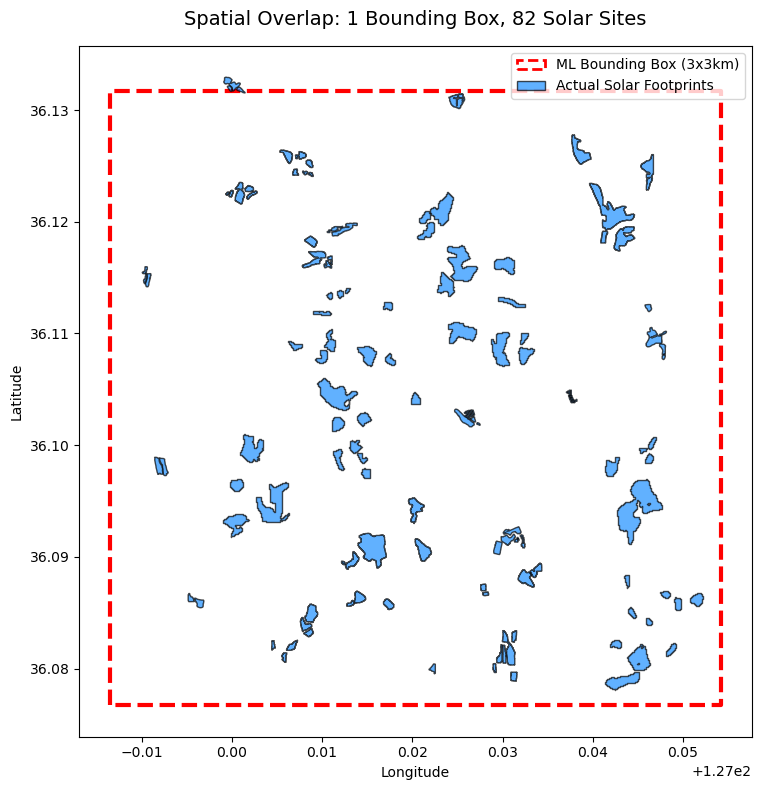

In [10]:
import matplotlib.patches as mpatches

# 1. Load the Data
gpkg_file = "global_solar_ml_pipeline.gpkg"
print("Loading positive datasets...")
base_train = gpd.read_file(gpkg_file, layer="base_train")
overflow = gpd.read_file(gpkg_file, layer="overflow")

# Combine all positive sites (we don't check negatives because they don't have solar farms)
#positives = pd.concat([base_train, overflow], ignore_index=True)
positives = base_train.copy()

# Convert the bounding boxes back to active geometries
positives['ml_bbox'] = gpd.GeoSeries.from_wkt(positives['ml_bbox'])

# 2. Isolate Geometries for the Spatial Join
# Create a GeoDataFrame of JUST the 3km bounding boxes
bboxes = gpd.GeoDataFrame(positives[['ml_bbox']], geometry='ml_bbox', crs=positives.crs)
bboxes['bbox_id'] = bboxes.index

# Create a GeoDataFrame of JUST the actual solar footprints
footprints = gpd.GeoDataFrame(positives[['geometry']], geometry='geometry', crs=positives.crs)
footprints['footprint_id'] = footprints.index

# 3. Perform the Spatial Join
# This asks: "For every bounding box, which footprints intersect it?"
print("Calculating spatial intersections (this takes a few seconds)...")
joined = gpd.sjoin(bboxes, footprints, how='inner', predicate='intersects')

# Count how many footprints fall into each bounding box
overlap_counts = joined.groupby('bbox_id').size()

# Filter down to boxes that contain MORE THAN ONE solar footprint
overlapping_bboxes = overlap_counts[overlap_counts > 1]

# --- NUMERICAL RESULTS ---
print("\n" + "="*40)
print("📊 OVERLAP ANALYSIS RESULTS")
print("="*40)
print(f"Total positive sites:                {len(bboxes):,}")
print(f"Boxes containing multiple sites:     {len(overlapping_bboxes):,}")
percentage = (len(overlapping_bboxes) / len(bboxes)) * 100
print(f"Percentage of dataset affected:      {percentage:.1f}%")
print("="*40)

# 4. Visualizing the Worst-Case Scenario
if len(overlapping_bboxes) > 0:
    # Find the single bounding box with the MAXIMUM number of solar arrays inside it
    worst_case_id = overlap_counts.idxmax()
    num_sites_in_worst = overlap_counts.max()

    print(f"\nPlotting worst-case scenario: Bounding Box #{worst_case_id} contains {num_sites_in_worst} separate solar arrays!")

    # Extract the geometries to plot
    worst_bbox = bboxes.loc[[worst_case_id]]
    intersecting_footprint_ids = joined[joined['bbox_id'] == worst_case_id]['footprint_id']
    worst_footprints = footprints.loc[intersecting_footprint_ids]

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot the 3km Bounding Box
    worst_bbox.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=3, linestyle='--')
    
    # Plot the actual Solar Footprints
    worst_footprints.plot(ax=ax, facecolor='dodgerblue', edgecolor='black', alpha=0.7)

    plt.title(f"Spatial Overlap: 1 Bounding Box, {num_sites_in_worst} Solar Sites", fontsize=14, pad=15)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Custom Legend
    red_patch = mpatches.Patch(edgecolor='red', facecolor='none', linewidth=2, linestyle='--', label='ML Bounding Box (3x3km)')
    blue_patch = mpatches.Patch(facecolor='dodgerblue', edgecolor='black', alpha=0.7, label='Actual Solar Footprints')
    plt.legend(handles=[red_patch, blue_patch], loc='upper right')

    plt.tight_layout()
    plt.savefig("overlap_example.png", dpi=300)
    plt.show()
else:
    print("No overlaps found! Your sites are completely isolated.")

In [ ]:
base_train_gdf

Loading base_train dataset...
Original number of sites: 38,599
Buffering footprints by 5km...
Dissolving overlapping regions...
Mapping original sites to new clusters...
Aggregating metadata...

🌍 CLUSTERING RESULTS
Original Individual Sites: 38,599
New Contiguous Clusters:   16,048
Compression Ratio:         2.4x reduction in API calls!


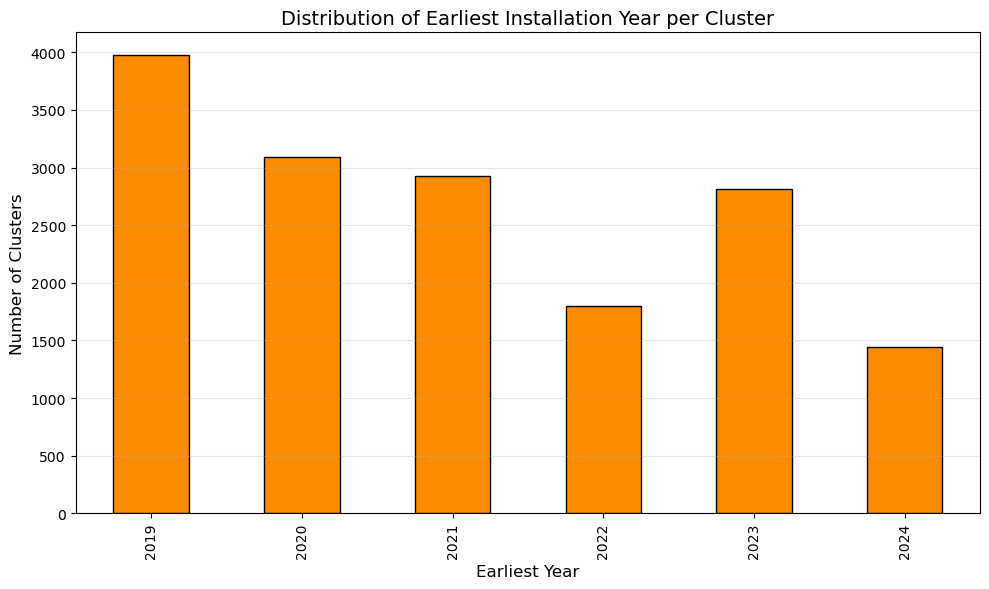

In [21]:
print("Loading base_train dataset...")
gpkg_file = "global_solar_ml_pipeline.gpkg"
# Load just the footprints
gdf = gpd.read_file(gpkg_file, layer="base_train")

# Ensure your CRS is a projected one (like EPSG:3857) so buffering is in meters
# If it's in EPSG:4326 (Lat/Lon degrees), project it first:
gdf = gdf.to_crs("EPSG:3857")

print(f"Original number of sites: {len(gdf):,}")

# 1. Create the 3km Buffers
# 5000 meters = 5km
print("Buffering footprints by 5km...")
gdf['buffer_geom'] = gdf.geometry.buffer(2500)

# Create a temporary GeoDataFrame just for dissolving
buffer_gdf = gpd.GeoDataFrame(gdf[['PV_ID', 'buffer_geom']], geometry='buffer_geom', crs=gdf.crs)

# 2. Dissolve Overlapping Buffers
print("Dissolving overlapping regions...")
# We add a dummy column just so dissolve has something to group by
buffer_gdf['dummy'] = 1 
dissolved = buffer_gdf.dissolve(by='dummy').explode(index_parts=False).reset_index(drop=True)

# Give each new massive continuous cluster a unique ID
dissolved['cluster_id'] = dissolved.index

# 3. Map Original Sites to the New Clusters
print("Mapping original sites to new clusters...")
# Spatial join the original footprints into the new dissolved clusters
joined = gpd.sjoin(gdf, dissolved[['cluster_id', 'buffer_geom']], how='inner', predicate='intersects')

# 4. Aggregate the Metadata!
print("Aggregating metadata...")
cluster_data = joined.groupby('cluster_id').agg(
    num_sites=('PV_ID', 'count'),
    original_site_ids=('PV_ID', lambda x: list(x)),
    total_area=('area_m2', 'sum'),           # Assuming you have an 'area' column
    earliest_year=('year', 'min')         # Assuming you have a 'year' column
).reset_index()

# Merge the aggregated data back with the spatial dissolved geometries
final_clusters = dissolved.merge(cluster_data, on='cluster_id')

print("\n" + "="*40)
print("🌍 CLUSTERING RESULTS")
print("="*40)
print(f"Original Individual Sites: {len(gdf):,}")
print(f"New Contiguous Clusters:   {len(final_clusters):,}")
print(f"Compression Ratio:         {len(gdf) / len(final_clusters):.1f}x reduction in API calls!")
print("="*40)

# 5. Plot the Year Distribution of the Clusters
plt.figure(figsize=(10, 6))
final_clusters['earliest_year'].value_counts().sort_index().plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Distribution of Earliest Installation Year per Cluster', fontsize=14)
plt.xlabel('Earliest Year', fontsize=12)
plt.ylabel('Number of Clusters', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# (Optional) Save this optimized dataset back to a new layer
# final_clusters.to_crs("EPSG:4326").to_file(gpkg_file, layer="base_train_clustered", driver="GPKG")

Loading footprints...
Running spatial parameter sweep...
Guaranteeing 1km separation resulted in 22,038 clusters.
Guaranteeing 2km separation resulted in 20,022 clusters.
Guaranteeing 3km separation resulted in 18,547 clusters.
Guaranteeing 4km separation resulted in 17,215 clusters.
Guaranteeing 5km separation resulted in 16,052 clusters.
Guaranteeing 6km separation resulted in 15,021 clusters.
Guaranteeing 7km separation resulted in 14,061 clusters.
Guaranteeing 8km separation resulted in 13,189 clusters.
Guaranteeing 9km separation resulted in 12,457 clusters.
Guaranteeing 10km separation resulted in 11,790 clusters.
Guaranteeing 11km separation resulted in 11,127 clusters.
Guaranteeing 12km separation resulted in 10,498 clusters.
Guaranteeing 13km separation resulted in 9,987 clusters.
Guaranteeing 14km separation resulted in 9,473 clusters.
Guaranteeing 15km separation resulted in 9,005 clusters.
Guaranteeing 16km separation resulted in 8,543 clusters.
Guaranteeing 17km separation

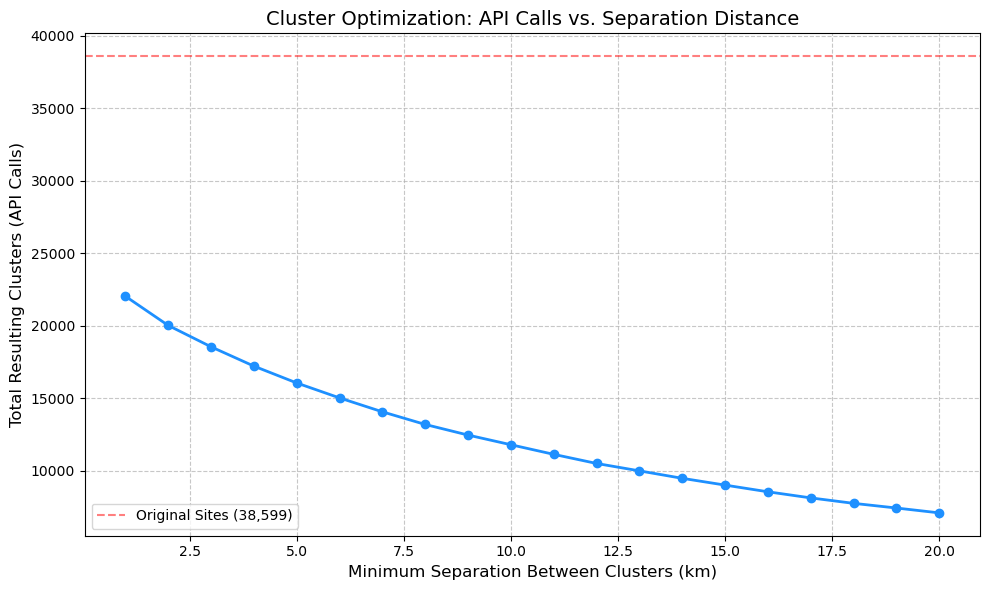

In [16]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("Loading footprints...")
gdf = gpd.read_file("global_solar_ml_pipeline.gpkg", layer="base_train")
gdf = gdf.to_crs("EPSG:3857") # Ensure metric projection

# We want to test "Minimum Separation Distances" of 2km, 4km, 6km, 8km, 10km
# To achieve a separation distance of X, we buffer by X / 2.
separation_distances_km = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
results = []

print("Running spatial parameter sweep...")

for sep_km in separation_distances_km:
    buffer_radius_meters = (sep_km * 1000) / 2
    
    # 1. Buffer
    temp_gdf = gpd.GeoDataFrame(geometry=gdf.geometry.buffer(buffer_radius_meters))
    temp_gdf['dummy'] = 1
    
    # 2. Dissolve
    dissolved = temp_gdf.dissolve(by='dummy').explode(index_parts=False)
    
    # Record the results
    cluster_count = len(dissolved)
    results.append({
        'Separation_km': sep_km,
        'Cluster_Count': cluster_count,
        'Compression_Ratio': len(gdf) / cluster_count
    })
    print(f"Guaranteeing {sep_km}km separation resulted in {cluster_count:,} clusters.")

# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(results)

# 3. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(results_df['Separation_km'], results_df['Cluster_Count'], marker='o', linewidth=2, color='dodgerblue')
plt.title("Cluster Optimization: API Calls vs. Separation Distance", fontsize=14)
plt.xlabel("Minimum Separation Between Clusters (km)", fontsize=12)
plt.ylabel("Total Resulting Clusters (API Calls)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate the original count for perspective
plt.axhline(y=len(gdf), color='red', linestyle='--', alpha=0.5, label=f"Original Sites ({len(gdf):,})")
plt.legend()
plt.tight_layout()
plt.show()

Loading footprints...
Running spatial parameter sweep with area tracking...
1km separation -> 22,038 clusters (Avg Area: 2.37 sq km)
2km separation -> 20,022 clusters (Avg Area: 6.35 sq km)
3km separation -> 18,547 clusters (Avg Area: 12.45 sq km)
4km separation -> 17,215 clusters (Avg Area: 20.97 sq km)
5km separation -> 16,052 clusters (Avg Area: 32.08 sq km)
6km separation -> 15,021 clusters (Avg Area: 45.99 sq km)
7km separation -> 14,061 clusters (Avg Area: 63.04 sq km)
8km separation -> 13,189 clusters (Avg Area: 83.42 sq km)
9km separation -> 12,457 clusters (Avg Area: 106.80 sq km)
10km separation -> 11,790 clusters (Avg Area: 133.64 sq km)
11km separation -> 11,127 clusters (Avg Area: 164.88 sq km)
12km separation -> 10,498 clusters (Avg Area: 200.64 sq km)
13km separation -> 9,987 clusters (Avg Area: 239.26 sq km)
14km separation -> 9,473 clusters (Avg Area: 283.28 sq km)
15km separation -> 9,005 clusters (Avg Area: 331.73 sq km)
16km separation -> 8,543 clusters (Avg Area: 3

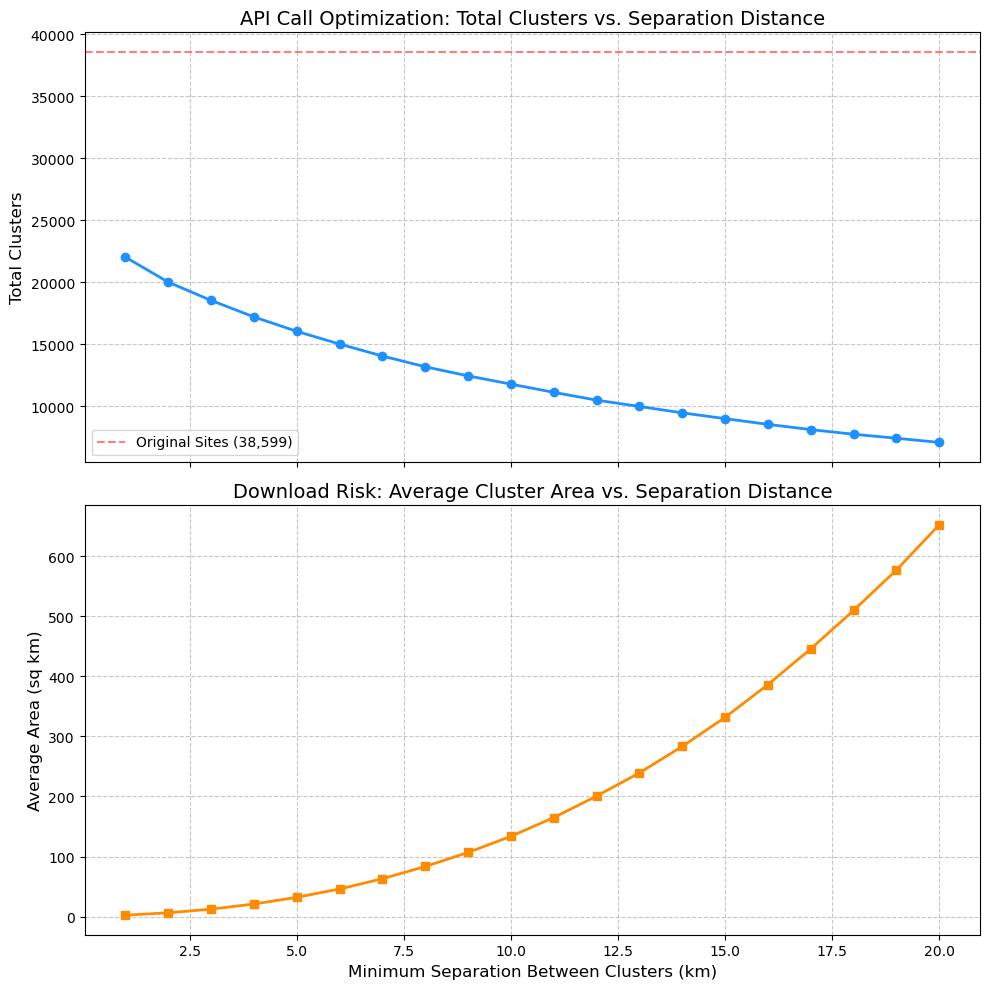

In [17]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("Loading footprints...")
gdf = gpd.read_file("global_solar_ml_pipeline.gpkg", layer="base_train")

# Ensure metric projection so our area calculations are in square meters
gdf = gdf.to_crs("EPSG:3857") 

separation_distances_km = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
results = []

print("Running spatial parameter sweep with area tracking...")

for sep_km in separation_distances_km:
    buffer_radius_meters = (sep_km * 1000) / 2
    
    # 1. Buffer & Dissolve
    temp_gdf = gpd.GeoDataFrame(geometry=gdf.geometry.buffer(buffer_radius_meters))
    temp_gdf['dummy'] = 1
    dissolved = temp_gdf.dissolve(by='dummy').explode(index_parts=False)
    
    # 2. Calculate the Average Area
    # EPSG:3857 area is in square meters. We divide by 1,000,000 to get square kilometers.
    dissolved['area_sqkm'] = dissolved.geometry.area / 1e6
    avg_area = dissolved['area_sqkm'].mean()
    
    # Record results
    cluster_count = len(dissolved)
    results.append({
        'Separation_km': sep_km,
        'Cluster_Count': cluster_count,
        'Avg_Cluster_Area_sqkm': avg_area,
        'Compression_Ratio': len(gdf) / cluster_count
    })
    print(f"{sep_km}km separation -> {cluster_count:,} clusters (Avg Area: {avg_area:.2f} sq km)")

# Convert to DataFrame
results_df = pd.DataFrame(results)

# 3. Plotting the Dual Metrics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Top Subplot: API Calls (Cluster Count)
ax1.plot(results_df['Separation_km'], results_df['Cluster_Count'], marker='o', linewidth=2, color='dodgerblue')
ax1.set_title("API Call Optimization: Total Clusters vs. Separation Distance", fontsize=14)
ax1.set_ylabel("Total Clusters", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(y=len(gdf), color='red', linestyle='--', alpha=0.5, label=f"Original Sites ({len(gdf):,})")
ax1.legend()

# Bottom Subplot: Download Size (Average Area)
ax2.plot(results_df['Separation_km'], results_df['Avg_Cluster_Area_sqkm'], marker='s', linewidth=2, color='darkorange')
ax2.set_title("Download Risk: Average Cluster Area vs. Separation Distance", fontsize=14)
ax2.set_xlabel("Minimum Separation Between Clusters (km)", fontsize=12)
ax2.set_ylabel("Average Area (sq km)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Loading footprints...
Running spatial parameter sweep with MAX Area tracking...
1km -> Clusters: 22,038 | Avg Area: 2.4 sq km | MAX Area: 181.3 sq km
2km -> Clusters: 20,022 | Avg Area: 6.3 sq km | MAX Area: 217.6 sq km
3km -> Clusters: 18,547 | Avg Area: 12.4 sq km | MAX Area: 268.9 sq km
4km -> Clusters: 17,215 | Avg Area: 21.0 sq km | MAX Area: 491.0 sq km
5km -> Clusters: 16,052 | Avg Area: 32.1 sq km | MAX Area: 697.0 sq km
6km -> Clusters: 15,021 | Avg Area: 46.0 sq km | MAX Area: 1198.5 sq km
7km -> Clusters: 14,061 | Avg Area: 63.0 sq km | MAX Area: 2205.7 sq km
8km -> Clusters: 13,189 | Avg Area: 83.4 sq km | MAX Area: 5181.6 sq km
9km -> Clusters: 12,457 | Avg Area: 106.8 sq km | MAX Area: 13454.9 sq km
10km -> Clusters: 11,790 | Avg Area: 133.6 sq km | MAX Area: 18027.3 sq km
11km -> Clusters: 11,127 | Avg Area: 164.9 sq km | MAX Area: 24360.0 sq km
12km -> Clusters: 10,498 | Avg Area: 200.6 sq km | MAX Area: 26175.5 sq km
13km -> Clusters: 9,987 | Avg Area: 239.3 sq km | MA

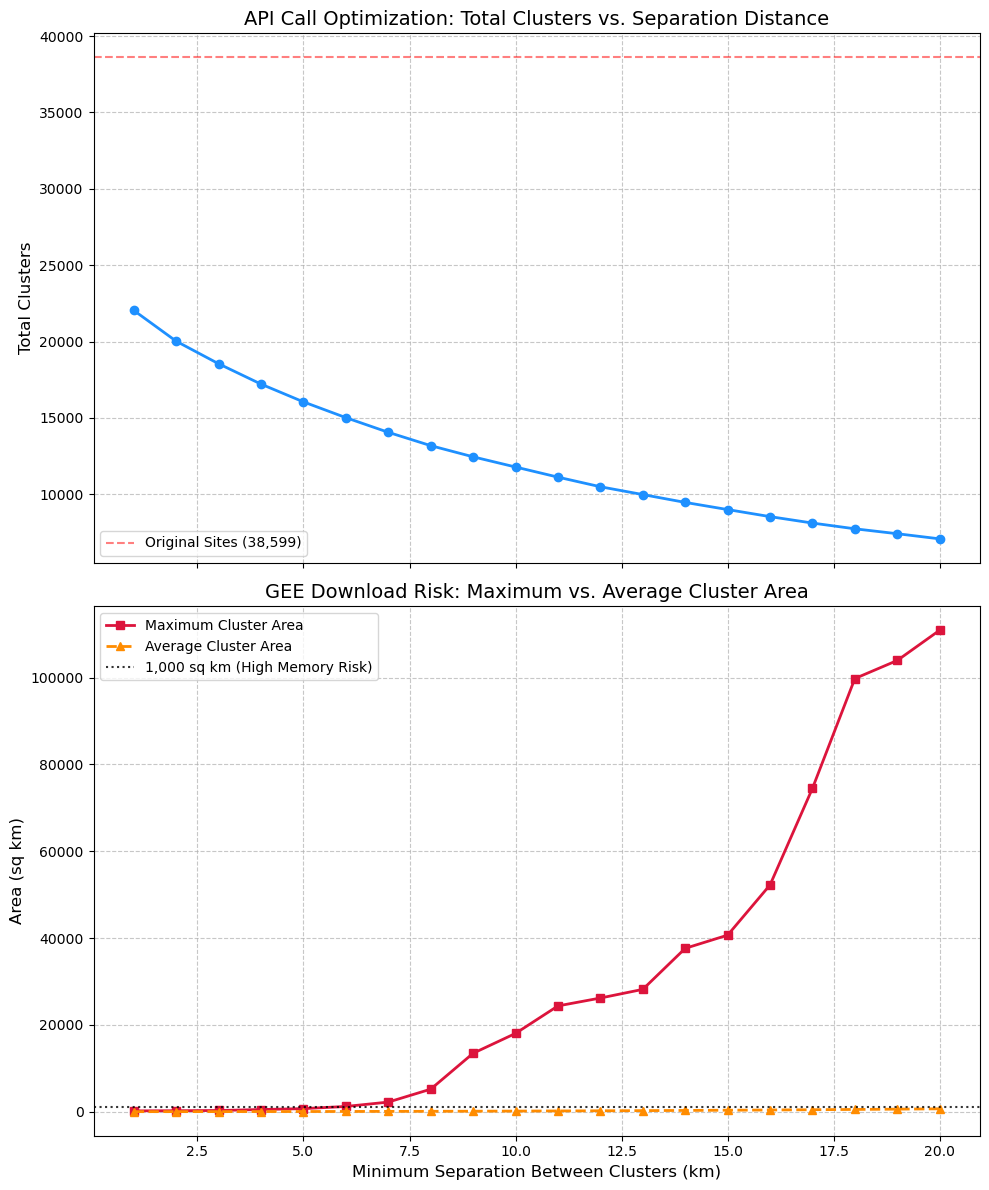

In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("Loading footprints...")
gdf = gpd.read_file("global_solar_ml_pipeline.gpkg", layer="base_train")

# Ensure metric projection so our area calculations are in square meters
gdf = gdf.to_crs("EPSG:3857") 

# Testing from 1km to 20km based on your previous run
separation_distances_km = list(range(1, 21))
results = []

print("Running spatial parameter sweep with MAX Area tracking...")

for sep_km in separation_distances_km:
    buffer_radius_meters = (sep_km * 1000) / 2
    
    # 1. Buffer & Dissolve
    temp_gdf = gpd.GeoDataFrame(geometry=gdf.geometry.buffer(buffer_radius_meters))
    temp_gdf['dummy'] = 1
    dissolved = temp_gdf.dissolve(by='dummy').explode(index_parts=False)
    
    # 2. Calculate the Areas
    dissolved['area_sqkm'] = dissolved.geometry.area / 1e6
    avg_area = dissolved['area_sqkm'].mean()
    max_area = dissolved['area_sqkm'].max() # <-- The true danger metric
    
    # Record results
    cluster_count = len(dissolved)
    results.append({
        'Separation_km': sep_km,
        'Cluster_Count': cluster_count,
        'Avg_Area_sqkm': avg_area,
        'Max_Area_sqkm': max_area
    })
    print(f"{sep_km}km -> Clusters: {cluster_count:,} | Avg Area: {avg_area:.1f} sq km | MAX Area: {max_area:.1f} sq km")

# Convert to DataFrame
results_df = pd.DataFrame(results)

# 3. Plotting the Dual Metrics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Top Subplot: API Calls (Cluster Count)
ax1.plot(results_df['Separation_km'], results_df['Cluster_Count'], marker='o', linewidth=2, color='dodgerblue')
ax1.set_title("API Call Optimization: Total Clusters vs. Separation Distance", fontsize=14)
ax1.set_ylabel("Total Clusters", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(y=len(gdf), color='red', linestyle='--', alpha=0.5, label=f"Original Sites ({len(gdf):,})")
ax1.legend()

# Bottom Subplot: Download Risk (Max vs Avg Area)
ax2.plot(results_df['Separation_km'], results_df['Max_Area_sqkm'], marker='s', linewidth=2, color='crimson', label='Maximum Cluster Area')
ax2.plot(results_df['Separation_km'], results_df['Avg_Area_sqkm'], marker='^', linewidth=2, color='darkorange', linestyle='--', label='Average Cluster Area')

# Add a warning threshold (1,000 sq km is a huge 10m resolution image)
ax2.axhline(y=1000, color='black', linestyle=':', alpha=0.8, label="1,000 sq km (High Memory Risk)")

ax2.set_title("GEE Download Risk: Maximum vs. Average Cluster Area", fontsize=14)
ax2.set_xlabel("Minimum Separation Between Clusters (km)", fontsize=12)
ax2.set_ylabel("Area (sq km)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

In [22]:
import geopandas as gpd
import pandas as pd

def generate_ml_export_clusters(gdf, separation_km=5.0, padding_km=1.5, 
                                id_col='PV_ID', area_col='area_m2', year_col='year'):
    """
    Optimizes a dataset of solar footprints by clustering nearby sites and 
    generating tight rectangular bounding boxes for efficient Earth Engine exports.
    """
    print(f"🚀 Starting optimization: {separation_km}km separation, {padding_km}km ML padding.")
    print(f"Initial sites: {len(gdf):,}")
    
    # 1. Project to a metric CRS for accurate distance math
    working_gdf = gdf.copy()
    if working_gdf.crs != "EPSG:3857":
        working_gdf = working_gdf.to_crs("EPSG:3857")
        
    # 1.5 SANITIZE GEOMETRIES (Modern topological repair)
    print("Sanitizing geometries...")
    working_gdf.geometry = working_gdf.geometry.make_valid()
        
    # 2. Buffer to find overlapping clusters (Buffer = Separation / 2)
    buffer_radius_meters = (separation_km * 1000) / 2
    working_gdf['cluster_buffer'] = working_gdf.geometry.buffer(buffer_radius_meters)
    
    buffer_gdf = gpd.GeoDataFrame(working_gdf[[id_col, 'cluster_buffer']], geometry='cluster_buffer', crs=working_gdf.crs)
    buffer_gdf['dummy'] = 1
    
    # 3. Dissolve to create the continuous regions
    print("Dissolving regions...")
    # Micro-buffer the cluster buffer to prevent side-location conflicts here too
    buffer_gdf.geometry = buffer_gdf.geometry.buffer(0.01).make_valid()
    dissolved = buffer_gdf.dissolve(by='dummy').explode(index_parts=False).reset_index(drop=True)
    dissolved['cluster_id'] = dissolved.index
    
    # 4. Map original sites back to the new cluster IDs
    joined = gpd.sjoin(working_gdf, dissolved[['cluster_id', 'cluster_buffer']], how='inner', predicate='intersects')
    
    # 5. Aggregate the Metadata
    print("Aggregating metadata...")
    cluster_data = joined.groupby('cluster_id').agg(
        num_sites=(id_col, 'count'),
        original_site_ids=(id_col, lambda x: list(x)),
        total_area=(area_col, 'sum'),
        target_year=(year_col, 'min') # Minimum year becomes the target year
    ).reset_index()
    
    # 6. The "Shrink-Wrap" Trick (WITH FLOATING-POINT FIX)
    print("Shrink-wrapping clusters...")
    
    # Apply a 1-centimeter buffer to force vertex snapping and prevent GEOS conflicts
    shrink_wrap_gdf = joined.copy()
    shrink_wrap_gdf.geometry = shrink_wrap_gdf.geometry.buffer(0.01).make_valid()
    
    tight_clusters = shrink_wrap_gdf.dissolve(by='cluster_id')
    tight_envelopes = tight_clusters.envelope
    
    padding_meters = padding_km * 1000
    final_geometries = tight_envelopes.buffer(padding_meters).envelope
    
    # 7. Merge everything together
    final_gdf = gpd.GeoDataFrame(cluster_data, geometry=final_geometries.values, crs=working_gdf.crs)
    
    # Calculate the final area of the rectangular export box
    final_gdf['export_area_sqkm'] = final_gdf.geometry.area / 1e6
    
    # 8. Project back to EPSG:4326 (Lat/Lon) because Earth Engine requires it!
    final_gdf = final_gdf.to_crs("EPSG:4326")
    
    print("\n✅ OPTIMIZATION COMPLETE")
    print(f"Final Clusters (API Calls): {len(final_gdf):,}")
    print(f"Compression Ratio:          {len(gdf) / len(final_gdf):.1f}x reduction")
    print(f"Max Export Area:            {final_gdf['export_area_sqkm'].max():.1f} sq km")
    
    return final_gdf

In [28]:
# Load your raw data
gpkg_file = "global_solar_ml_pipeline.gpkg"
raw_train_gdf = gpd.read_file(gpkg_file, layer="base_train")

# Run the magic function!
# (Note: I set padding to 1.5km so an isolated point gets a 3x3km box. 
# If you want a 6x6km box, change padding_km to 3.0)
optimized_train_gdf = generate_ml_export_clusters(
    gdf=raw_train_gdf, 
    separation_km=5.0, 
    padding_km=2,
    id_col='PV_ID',      # Make sure this matches your dataset exactly!
    area_col='area_m2',  # Make sure this matches your dataset exactly!
    year_col='year'      # Make sure this matches your dataset exactly!
)

# Save it back to your GeoPackage for the Earth Engine script to read
optimized_train_gdf.to_file(gpkg_file, layer="base_train_export_ready", driver="GPKG")

🚀 Starting optimization: 5.0km separation, 2km ML padding.
Initial sites: 38,599
Sanitizing geometries...
Dissolving regions...
Aggregating metadata...
Shrink-wrapping clusters...

✅ OPTIMIZATION COMPLETE
Final Clusters (API Calls): 16,048
Compression Ratio:          2.4x reduction
Max Export Area:            2026.0 sq km


In [29]:
import geopandas as gpd

gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading datasets...")
# Load the newly optimized positive clusters
pos_gdf = gpd.read_file(gpkg_file, layer="base_train_export_ready")
# Load your negative dataset
neg_gdf = gpd.read_file(gpkg_file, layer="negative")

print("Projecting to metric CRS for accurate area calculation...")
# EPSG:3857 allows us to calculate area in square meters
pos_gdf = pos_gdf.to_crs("EPSG:3857")
neg_gdf = neg_gdf.to_crs("EPSG:3857")

# Calculate total area in square kilometers
pos_total_area = pos_gdf.geometry.area.sum() / 1e6
neg_total_area = neg_gdf.geometry.area.sum() / 1e6

ratio = neg_total_area / pos_total_area

print("\n" + "="*40)
print("⚖️ DATASET BALANCE ANALYSIS (By Area)")
print("="*40)
print(f"Total Positive Area: {pos_total_area:,.1f} sq km")
print(f"Total Negative Area: {neg_total_area:,.1f} sq km")
print("-" * 40)

if ratio > 1:
    print(f"Your Negative dataset is {ratio:.1f}x LARGER than your Positive dataset.")
elif ratio < 1:
    print(f"Your Positive dataset is {1/ratio:.1f}x LARGER than your Negative dataset.")
else:
    print("Your datasets are perfectly balanced by area!")
print("="*40)

Loading datasets...
Projecting to metric CRS for accurate area calculation...

⚖️ DATASET BALANCE ANALYSIS (By Area)
Total Positive Area: 529,799.9 sq km
Total Negative Area: 1,885,460.0 sq km
----------------------------------------
Your Negative dataset is 3.6x LARGER than your Positive dataset.


In [31]:
import geopandas as gpd
import pandas as pd

gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading datasets...")
# 1. Load your raw positives (for country proportions and audit)
pos_orig_gdf = gpd.read_file(gpkg_file, layer="base_train")
# 2. Load your new clustered positives (for the exact target area we need to hit)
pos_clustered_gdf = gpd.read_file(gpkg_file, layer="base_train_export_ready")
# 3. Load the negatives we need to shrink
neg_gdf = gpd.read_file(gpkg_file, layer="negative")

# Ensure the column exists (handling potential capitalization differences)
# If your column is named 'Country' with a capital C, change the string below!
COUNTRY_COL = 'country' 

if COUNTRY_COL not in pos_orig_gdf.columns or COUNTRY_COL not in neg_gdf.columns:
    raise ValueError(f"Could not find the '{COUNTRY_COL}' column in one or both datasets. Please check the exact column name.")

print("Projecting to metric CRS for accurate area calculations...")
pos_orig_gdf = pos_orig_gdf.to_crs("EPSG:3857")
pos_clustered_gdf = pos_clustered_gdf.to_crs("EPSG:3857")
neg_gdf = neg_gdf.to_crs("EPSG:3857")

# --- PHASE 1: THE COUNTRY AUDIT ---
# Drop any accidental NaNs to keep the sets clean
pos_countries = set(pos_orig_gdf[COUNTRY_COL].dropna().unique())
neg_countries = set(neg_gdf[COUNTRY_COL].dropna().unique())

print("\n" + "="*40)
print("🌍 COUNTRY REPRESENTATION AUDIT")
print("="*40)
print(f"Countries with Positive sites: {len(pos_countries)}")
print(f"Countries with Negative sites: {len(neg_countries)}")

missing_in_neg = pos_countries - neg_countries

if missing_in_neg:
    print(f"\n⚠️ CRITICAL WARNING: You have solar sites in these {len(missing_in_neg)} countries, but NO negatives:")
    for c in sorted(missing_in_neg):
        print(f"  - {c}")
else:
    print("\n✅ Perfect! Every positive country has negative representation.")

# --- PHASE 2: STRATIFIED DOWNSAMPLING ---
print("\n" + "="*40)
print("✂️ RUNNING STRATIFIED DOWNSAMPLING")
print("="*40)

# Calculate total target area (the area of our new clustered positives)
target_total_area = pos_clustered_gdf.geometry.area.sum() / 1e6

# Calculate the proportional area each country SHOULD have based on the original dataset
pos_orig_gdf['area_sqkm'] = pos_orig_gdf.geometry.area / 1e6
country_proportions = pos_orig_gdf.groupby(COUNTRY_COL)['area_sqkm'].sum() / pos_orig_gdf['area_sqkm'].sum()
target_area_per_country = country_proportions * target_total_area

neg_gdf['area_sqkm'] = neg_gdf.geometry.area / 1e6
kept_indices = []

for country in neg_countries:
    country_negs = neg_gdf[neg_gdf[COUNTRY_COL] == country].copy()
    
    # Target area for this specific country
    target_area = target_area_per_country.get(country, 0)
    
    # Shuffle the sites randomly
    country_negs = country_negs.sample(frac=1.0, random_state=42)
    
    # Calculate cumulative area of the shuffled sites
    country_negs['cum_area'] = country_negs['area_sqkm'].cumsum()
    
    # Keep sites until we hit the target area
    kept = country_negs[country_negs['cum_area'] <= target_area]
    
    # THE GUARANTEE: If the math eliminated the country entirely, force keep 1 site!
    if kept.empty and not country_negs.empty:
        kept = country_negs.iloc[[0]]
        
    kept_indices.extend(kept.index.tolist())

# Create the final optimized dataset
final_neg_gdf = neg_gdf.loc[kept_indices].copy()
final_neg_gdf = final_neg_gdf.drop(columns=['area_sqkm', 'cum_area'], errors='ignore')

# --- PHASE 3: VERIFICATION ---
final_neg_area = final_neg_gdf.geometry.area.sum() / 1e6
ratio = final_neg_area / target_total_area

print(f"Target Positive Area: {target_total_area:,.1f} sq km")
print(f"Achieved Neg Area:    {final_neg_area:,.1f} sq km")
print(f"Final Balance Ratio:  {ratio:.2f}x (Negatives to Positives)")
print(f"Original Neg Sites:   {len(neg_gdf):,}")
print(f"Remaining Neg Sites:  {len(final_neg_gdf):,}")

# Project back to EPSG:4326 for Earth Engine and save
print("\nSaving balanced negative dataset...")
final_neg_gdf.to_crs("EPSG:4326").to_file(gpkg_file, layer="base_train_negatives_balanced", driver="GPKG")
print("✅ Done! Saved as 'base_train_negatives_balanced'")

Loading datasets...
Projecting to metric CRS for accurate area calculations...

🌍 COUNTRY REPRESENTATION AUDIT
Countries with Positive sites: 165
Countries with Negative sites: 150

⚠️ CRITICAL WARNING: You have solar sites in these 15 countries, but NO negatives:
  - Akrotiri Sovereign Base Area
  - Anguilla
  - British Indian Ocean Territory
  - Comoros
  - Cook Islands
  - Dhekelia Sovereign Base Area
  - Federated States of Micronesia
  - Kiribati
  - Macao S.A.R
  - Nauru
  - Palau
  - Saint Vincent and the Grenadines
  - Seychelles
  - US Naval Base Guantanamo Bay
  - United States Minor Outlying Islands

✂️ RUNNING STRATIFIED DOWNSAMPLING
Target Positive Area: 529,799.9 sq km
Achieved Neg Area:    497,526.3 sq km
Final Balance Ratio:  0.94x (Negatives to Positives)
Original Neg Sites:   38,564
Remaining Neg Sites:  11,267

Saving balanced negative dataset...
✅ Done! Saved as 'base_train_negatives_balanced'


In [32]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import box
import math

gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading datasets...")
pos_orig_gdf = gpd.read_file(gpkg_file, layer="base_train")
neg_balanced_gdf = gpd.read_file(gpkg_file, layer="base_train_negatives_balanced")

# Ensure projected CRS for accurate meter-based math
pos_orig_gdf = pos_orig_gdf.to_crs("EPSG:3857")
neg_balanced_gdf = neg_balanced_gdf.to_crs("EPSG:3857")

missing_countries = [
    "Akrotiri Sovereign Base Area", "Anguilla", "British Indian Ocean Territory", 
    "Comoros", "Cook Islands", "Dhekelia Sovereign Base Area", 
    "Federated States of Micronesia", "Kiribati", "Macao S.A.R", 
    "Nauru", "Palau", "Saint Vincent and the Grenadines", 
    "Seychelles", "US Naval Base Guantanamo Bay", "United States Minor Outlying Islands"
]

COUNTRY_COL = 'country' 
HALF_BOX_METERS = 2560  # Exactly 512x512 pixels at 10m resolution
EXCLUSION_BUFFER = 5000 # Must be 5km away from any solar site

print(f"\nSearching for safe negative sites for {len(missing_countries)} micro-states...")

new_negatives = []

for country in missing_countries:
    country_positives = pos_orig_gdf[pos_orig_gdf[COUNTRY_COL] == country]
    found_safe_spot = False
    
    # Iterate through the country's solar sites to use as jumping-off points
    for idx, site in country_positives.iterrows():
        if found_safe_spot: break
            
        cx, cy = site.geometry.centroid.x, site.geometry.centroid.y
        
        # Try shifting by 8km, then 15km, then 25km if it keeps hitting exclusion zones
        for dist in [8000, 15000, 25000]: 
            if found_safe_spot: break
                
            # Try 8 different compass directions (0, 45, 90, 135, 180...)
            for angle in range(0, 360, 45):
                rad = math.radians(angle)
                new_x = cx + (dist * math.cos(rad))
                new_y = cy + (dist * math.sin(rad))
                
                # 1. Build the exact 5120m x 5120m bounding box
                new_bbox = box(
                    new_x - HALF_BOX_METERS, 
                    new_y - HALF_BOX_METERS, 
                    new_x + HALF_BOX_METERS, 
                    new_y + HALF_BOX_METERS
                )
                
                # 2. The Exclusion Zone Check (Fast Spatial Index Math)
                search_area = new_bbox.buffer(EXCLUSION_BUFFER)
                possible_matches_idx = list(pos_orig_gdf.sindex.intersection(search_area.bounds))
                possible_matches = pos_orig_gdf.iloc[possible_matches_idx]
                precise_matches = possible_matches[possible_matches.intersects(search_area)]
                
                # 3. If zero intersections, it's a perfectly safe location!
                if len(precise_matches) == 0:
                    new_row = {
                        COUNTRY_COL: country,
                        'geometry': new_bbox,
                        'source': 'synthetic_safe_shift'
                    }
                    new_negatives.append(new_row)
                    found_safe_spot = True
                    break

if new_negatives:
    new_neg_gdf = gpd.GeoDataFrame(new_negatives, crs="EPSG:3857")
    
    # Append the new perfectly sized sites
    final_neg_gdf = pd.concat([neg_balanced_gdf, new_neg_gdf], ignore_index=True)
    
    print("\n" + "="*40)
    print("📈 FINAL PIPELINE METRICS (GEE WORKLOAD)")
    print("="*40)
    print(f"Original Negative Targets:       38,564 chips")
    print(f"Final Optimized Negative Targets: {len(final_neg_gdf):,} chips")
    
    reduction = 100 - ((len(final_neg_gdf) / 38564) * 100)
    print(f"Total Negative API Reduction:     {reduction:.1f}%")
    print("="*40)
    
    # Project back to EPSG:4326 for GEE and save
    print("\nSaving final appended dataset...")
    final_neg_gdf.to_crs("EPSG:4326").to_file(gpkg_file, layer="base_train_negatives_balanced", driver="GPKG")
    print("✅ Done! Your negative dataset is geographically complete, strictly sized, and safely buffered.")
else:
    print("Could not find anchor sites for the missing countries.")

Loading datasets...

Searching for safe negative sites for 15 micro-states...

📈 FINAL PIPELINE METRICS (GEE WORKLOAD)
Original Negative Targets:       38,564 chips
Final Optimized Negative Targets: 11,282 chips
Total Negative API Reduction:     70.7%

Saving final appended dataset...
✅ Done! Your negative dataset is geographically complete, strictly sized, and safely buffered.


In [ ]:
pos_gdf

In [39]:
import geopandas as gpd
import numpy as np

gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading balanced negative dataset...")
gdf = gpd.read_file(gpkg_file, layer="base_train_negatives_balanced")

# Isolate the 15 synthetic sites we added
# If you ran the script exactly as provided, they are tagged with 'synthetic_safe_shift'
synthetic_mask = gdf['source'] == 'synthetic_safe_shift'
num_synthetic = synthetic_mask.sum()

print(f"Found {num_synthetic} synthetic sites requiring schema backfill.")

if num_synthetic > 0:
    # Set seed so your randomized years don't change every time you run this cell
    np.random.seed(42) 

    # Loop through just those 15 rows and update them
    for idx, row in gdf[synthetic_mask].iterrows():
        
        # 1. Generate the ID (e.g., "Macao S.A.R" -> "MAC", ID -> "NEG_MAC_1")
        country_str = str(row['country'])
        short_code = country_str[:3].upper().replace(" ", "")
        pv_id = f"NEG_{short_code}_1"
        
        # 2. Randomize target year (2018 to 2023 inclusive)
        # Your example had it as a float (2022.0), so we will cast it to match
        target_year = float(np.random.randint(2018, 2024))
        
        # 3. Generate filename
        filename = f"{pv_id}_{int(target_year)}.tif"
        
        # 4. Extract Lat/Lon from the center of the geometry
        centroid = row.geometry.centroid
        
        # Update the dataframe
        gdf.at[idx, 'PV_ID'] = pv_id
        gdf.at[idx, 'target_year'] = target_year
        gdf.at[idx, 'exported'] = 'False' # Default boolean
        gdf.at[idx, 'export_filename'] = filename
        gdf.at[idx, 'dataset_split'] = 'unassigned'
        gdf.at[idx, 'area_m2'] = 0.0
        gdf.at[idx, 'latitude'] = centroid.y
        gdf.at[idx, 'longitude'] = centroid.x
        
        # Regarding ml_bbox: In GeoPandas, secondary geometry columns are often stored 
        # as WKT (Well-Known Text) strings. We'll duplicate the geometry as WKT here to be safe.
        gdf.at[idx, 'ml_bbox'] = row.geometry.wkt

    # Save it back to the GeoPackage
    gdf.to_file(gpkg_file, layer="base_train_negatives_balanced", driver="GPKG")
    print("\n✅ Schema perfectly aligned and saved back to the GeoPackage!")
    
    # Print one of the corrected rows to verify it matches your expectation
    print("\nVerification of a corrected row:")
    print(gdf[synthetic_mask].iloc[0][['PV_ID', 'country', 'target_year', 'export_filename', 'ml_bbox']])
else:
    print("No synthetic sites found. The dataset might already be fixed!")

Loading balanced negative dataset...
Found 15 synthetic sites requiring schema backfill.

✅ Schema perfectly aligned and saved back to the GeoPackage!

Verification of a corrected row:
PV_ID                                                      NEG_AKR_1
country                                 Akrotiri Sovereign Base Area
target_year                                                   2021.0
export_filename                                   NEG_AKR_1_2021.tif
ml_bbox            POLYGON ((33.09289217720704 34.5747596734696, ...
Name: 11267, dtype: object


In [41]:
import geopandas as gpd
import pandas as pd
from collections import Counter
import ast

gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading datasets...")
# We need the raw dataset to build our PV_ID -> Country lookup dictionary
orig_gdf = gpd.read_file(gpkg_file, layer="base_train")
pos_gdf = gpd.read_file(gpkg_file, layer="base_train_export_ready")

# Build a lightning-fast dictionary lookup: PV_ID -> Country
print("Building country lookup table...")
COUNTRY_COL = 'country' # Change to 'Country' if capitalized in your raw data
pv_to_country = dict(zip(orig_gdf['PV_ID'], orig_gdf[COUNTRY_COL]))

print("Backfilling positive cluster schema...")

for idx, row in pos_gdf.iterrows():
    # 1. Safely parse the original_site_ids string back into a Python list
    site_ids = row['original_site_ids']
    if isinstance(site_ids, str):
        try:
            site_ids = ast.literal_eval(site_ids)
        except:
            # Fallback string cleaner just in case
            site_ids = [s.strip() for s in site_ids.replace('[','').replace(']','').replace("'",'').replace('"','').split(',')]

    # 2. Look up the countries for all sites in this cluster
    countries = [pv_to_country.get(site_id) for site_id in site_ids if pv_to_country.get(site_id)]
    
    # 3. Determine the most common country (The Mode)
    if countries:
        most_common_country = Counter(countries).most_common(1)[0][0]
    else:
        most_common_country = "Unknown"
        
    # 4. Generate the new naming convention variables
    country_str = str(most_common_country)
    short_code = country_str[:3].upper().replace(" ", "")
    cluster_id = row['cluster_id']
    target_year = int(row['target_year'])
    
    pv_id = f"POS_{short_code}_{cluster_id}"
    filename = f"{pv_id}_{target_year}.tif"
    
    # 5. Inject the new data into the row
    pos_gdf.at[idx, 'country'] = most_common_country
    pos_gdf.at[idx, 'PV_ID'] = pv_id
    pos_gdf.at[idx, 'exported'] = 'False' # Wrapped in quotes to prevent Pandas type errors!
    pos_gdf.at[idx, 'export_filename'] = filename
    
    # 6. Add the ML metadata for PyTorch parity
    centroid = row.geometry.centroid
    pos_gdf.at[idx, 'latitude'] = centroid.y
    pos_gdf.at[idx, 'longitude'] = centroid.x
    pos_gdf.at[idx, 'dataset_split'] = 'unassigned'
    pos_gdf.at[idx, 'ml_bbox'] = row.geometry.wkt

print("Saving updated positive dataset to GeoPackage...")
pos_gdf.to_file(gpkg_file, layer="base_train_export_ready", driver="GPKG")
print("✅ Positive dataset schema perfectly aligned and saved!")

# Print a sample to verify it looks correct
print("\nSample Row Verification:")
print(pos_gdf.iloc[0][['PV_ID', 'country', 'target_year', 'export_filename']])

Loading datasets...
Building country lookup table...
Backfilling positive cluster schema...
Saving updated positive dataset to GeoPackage...
✅ Positive dataset schema perfectly aligned and saved!

Sample Row Verification:
PV_ID                       POS_COO_0
country                  Cook Islands
target_year                      2020
export_filename    POS_COO_0_2020.tif
Name: 0, dtype: object


In [48]:
import geopandas as gpd

gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading final optimized datasets...")
pos_gdf = gpd.read_file(gpkg_file, layer="base_train_export_ready")
neg_gdf = gpd.read_file(gpkg_file, layer="base_train_negatives_balanced")

# Project for accurate area calculation
pos_metric = pos_gdf.to_crs("EPSG:3857")
neg_metric = neg_gdf.to_crs("EPSG:3857")

print("\n" + "="*50)
print("🏆 FINAL PIPELINE INVENTORY")
print("="*50)

# Positive Stats
print("🌞 POSITIVE DATASET (base_train_export_ready)")
print(f"Total API Calls (Sites):  {len(pos_gdf):,}")
print(f"Total Area to Download:   {pos_metric.geometry.area.sum() / 1e6:,.1f} sq km")
print(f"Columns:                  {list(pos_gdf.columns)}")

print("\n" + "-"*50 + "\n")

# Negative Stats
print("🌑 NEGATIVE DATASET (base_train_negatives_balanced)")
print(f"Total API Calls (Sites):  {len(neg_gdf):,}")
print(f"Total Area to Download:   {neg_metric.geometry.area.sum() / 1e6:,.1f} sq km")
print(f"Columns:                  {list(neg_gdf.columns)}")

print("="*50)

Loading final optimized datasets...

🏆 FINAL PIPELINE INVENTORY
🌞 POSITIVE DATASET (base_train_export_ready)
Total API Calls (Sites):  16,048
Total Area to Download:   529,799.9 sq km
Columns:                  ['cluster_id', 'num_sites', 'original_site_ids', 'total_area', 'target_year', 'export_area_sqkm', 'country', 'PV_ID', 'exported', 'export_filename', 'latitude', 'longitude', 'dataset_split', 'ml_bbox', 'geometry']

--------------------------------------------------

🌑 NEGATIVE DATASET (base_train_negatives_balanced)
Total API Calls (Sites):  11,282
Total Area to Download:   497,919.5 sq km
Columns:                  ['PV_ID', 'country', 'target_year', 'exported', 'export_filename', 'dataset_split', 'area_m2', 'latitude', 'longitude', 'ml_bbox', 'source', 'geometry']


In [ ]:
pos_gdf

/tmp/ipykernel_30705/1813948774.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/solar-siting-ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


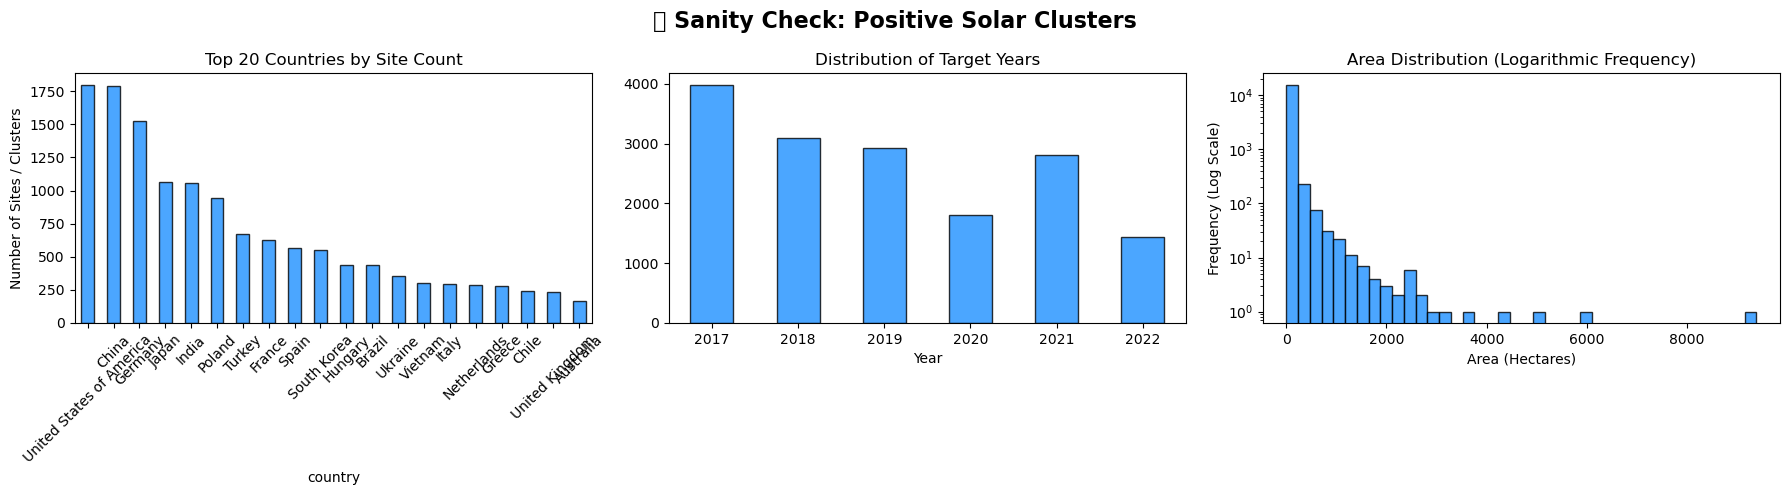

/tmp/ipykernel_30705/1813948774.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()
/tmp/ipykernel_30705/1813948774.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/solar-siting-ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


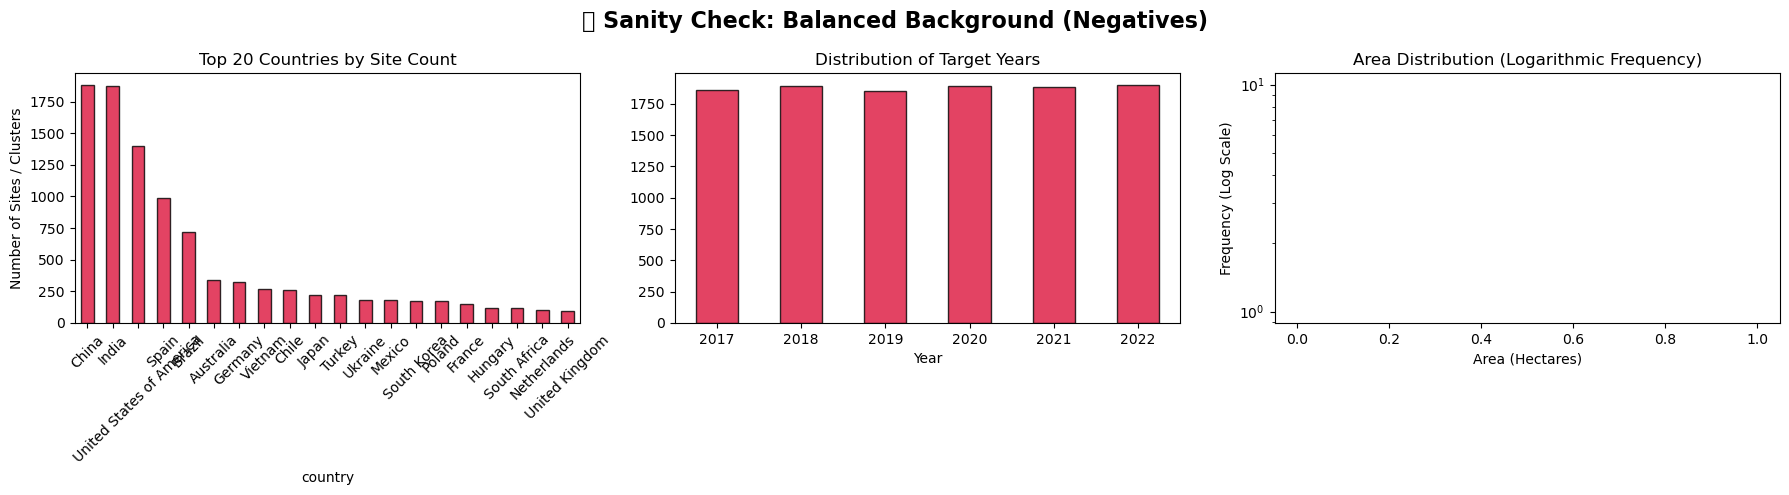

In [49]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

def plot_sanity_check(gdf, dataset_name, area_col, color_theme):
    """
    Generates a 1x3 dashboard for Country, Year, and Area distributions.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"🔍 Sanity Check: {dataset_name}", fontsize=16, fontweight='bold')

    # 1. COUNTRY DISTRIBUTION
    country_counts = gdf['country'].value_counts().head(20)
    country_counts.plot(kind='bar', ax=axes[0], color=color_theme, edgecolor='black', alpha=0.8)
    axes[0].set_title("Top 20 Countries by Site Count", fontsize=12)
    axes[0].set_ylabel("Number of Sites / Clusters")
    axes[0].tick_params(axis='x', rotation=45) 
    
    # 2. TARGET YEAR DISTRIBUTION
    valid_years = gdf['target_year'].dropna().astype(int)
    year_counts = valid_years.value_counts().sort_index()
    year_counts.plot(kind='bar', ax=axes[1], color=color_theme, edgecolor='black', alpha=0.8)
    axes[1].set_title("Distribution of Target Years", fontsize=12)
    axes[1].set_xlabel("Year")
    axes[1].tick_params(axis='x', rotation=0)

    # 3. AREA DISTRIBUTION (LOGARITHMIC)
    valid_areas = gdf[area_col].dropna()
    valid_areas = valid_areas[valid_areas > 0] 
    valid_areas_hectares = valid_areas / 10000
    
    # ADDED log=True here!
    axes[2].hist(valid_areas_hectares, bins=40, color=color_theme, edgecolor='black', alpha=0.8, log=True)
    axes[2].set_title(f"Area Distribution (Logarithmic Frequency)", fontsize=12)
    axes[2].set_xlabel("Area (Hectares)")
    axes[2].set_ylabel("Frequency (Log Scale)")

    plt.tight_layout()
    plt.show()

# Execution
gpkg_file = "global_solar_ml_pipeline.gpkg"
pos_gdf = gpd.read_file(gpkg_file, layer="base_train_export_ready")
neg_gdf = gpd.read_file(gpkg_file, layer="base_train_negatives_balanced")

plot_sanity_check(pos_gdf, "Positive Solar Clusters", 'total_area', 'dodgerblue')
plot_sanity_check(neg_gdf, "Balanced Background (Negatives)", 'area_m2', 'crimson')

In [46]:
# Replace this with the actual ID you want to inspect
target_id = "POS_MEX_9" 

# Filter the dataframe for that ID
# (Change to neg_gdf if you are inspecting a negative site)
inspected_row = pos_gdf[pos_gdf['PV_ID'] == target_id]

if not inspected_row.empty:
    print(f"--- Data for {target_id} ---")
    # Transposing it (.T) prints the columns vertically, which is much easier to read!
    print(inspected_row.iloc[0].T)
else:
    print(f"⚠️ Could not find {target_id} in the dataset.")

--- Data for POS_MEX_9 ---
cluster_id                                                           9
num_sites                                                            1
original_site_ids                                             [138190]
total_area                                                 9973.213481
target_year                                                       2019
export_area_sqkm                                             17.508151
country                                                         Mexico
PV_ID                                                        POS_MEX_9
exported                                                         False
export_filename                                     POS_MEX_9_2019.tif
latitude                                                     24.956996
longitude                                                  -111.626421
dataset_split                                               unassigned
ml_bbox              POLYGON ((-111.64536094917142

In [47]:
import geopandas as gpd
import numpy as np

gpkg_file = "global_solar_ml_pipeline.gpkg"

# ==========================================
# 1. FIX THE POSITIVE DATASET (T-2 Shift)
# ==========================================
print("Loading positive dataset...")
pos_gdf = gpd.read_file(gpkg_file, layer="base_train_export_ready")

print("Applying T-2 temporal shift to positive sites...")
# Convert to int, subtract 2
pos_gdf['target_year'] = pos_gdf['target_year'].astype(int) - 2

# Vectorized filename regeneration (fast!)
pos_gdf['export_filename'] = pos_gdf['PV_ID'] + "_" + pos_gdf['target_year'].astype(str) + ".tif"

# Save back to GPKG
pos_gdf.to_file(gpkg_file, layer="base_train_export_ready", driver="GPKG")
print("✅ Positive dataset updated successfully!")

# Print your specific test case to verify
test_id = "POS_MEX_9"
if not pos_gdf[pos_gdf['PV_ID'] == test_id].empty:
    print(f"\n--- Verification for {test_id} ---")
    print(pos_gdf[pos_gdf['PV_ID'] == test_id][['PV_ID', 'target_year', 'export_filename']].iloc[0])


# ==========================================
# 2. FIX THE NEGATIVE DATASET (Range Clamp)
# ==========================================
print("\nLoading negative dataset...")
neg_gdf = gpd.read_file(gpkg_file, layer="base_train_negatives_balanced")

# Ensure it's an integer for clean comparison
neg_gdf['target_year'] = neg_gdf['target_year'].astype(int)

# Create a mask for anything outside the 2017-2022 range
out_of_bounds_mask = (neg_gdf['target_year'] < 2017) | (neg_gdf['target_year'] > 2022)
num_out_of_bounds = out_of_bounds_mask.sum()

print(f"Found {num_out_of_bounds} negative sites outside the 2017-2022 range.")

if num_out_of_bounds > 0:
    print("Re-randomizing out-of-bounds years to the strict 2017-2022 range...")
    np.random.seed(42) # For reproducibility
    
    # Generate new random integers between 2017 and 2022 (inclusive)
    # np.random.randint's upper bound is exclusive, so we use 2023
    new_years = np.random.randint(2017, 2023, size=num_out_of_bounds)
    
    # Apply the new years only to the rows that were broken
    neg_gdf.loc[out_of_bounds_mask, 'target_year'] = new_years
    
    # Regenerate all negative filenames to ensure they are 100% accurate
    neg_gdf['export_filename'] = neg_gdf['PV_ID'] + "_" + neg_gdf['target_year'].astype(str) + ".tif"
    
    # Save back to GPKG
    neg_gdf.to_file(gpkg_file, layer="base_train_negatives_balanced", driver="GPKG")
    print("✅ Negative dataset updated successfully!")
else:
    print("No out-of-bounds years found. Negative dataset is already perfect.")

Loading positive dataset...
Applying T-2 temporal shift to positive sites...
✅ Positive dataset updated successfully!

--- Verification for POS_MEX_9 ---
PV_ID                       POS_MEX_9
target_year                      2017
export_filename    POS_MEX_9_2017.tif
Name: 9, dtype: object

Loading negative dataset...
Found 1 negative sites outside the 2017-2022 range.
Re-randomizing out-of-bounds years to the strict 2017-2022 range...
✅ Negative dataset updated successfully!


## GEE Export

In [8]:

# ==========================================
# 🧮 DYNAMIC UTM CALCULATOR
# ==========================================
def get_utm_epsg(lon, lat):
    """Calculates the local UTM EPSG code for any given Lat/Lon coordinate."""
    zone_number = math.floor((lon + 180) / 6) + 1
    # 32600 is Northern Hemisphere, 32700 is Southern Hemisphere
    epsg_code = 32600 + zone_number if lat >= 0 else 32700 + zone_number
    return f'EPSG:{epsg_code}'

# ==========================================
# 🎛️ BATCH CONTROL PANEL
# ==========================================
GPKG_FILE = "global_solar_ml_pipeline.gpkg"
DATASET_TO_RUN = "positive"  # Toggle between "positive" and "negative"
BATCH_SIZE = 1000            # Safe batch chunk
DRIVE_FOLDER = "aef_solar_chips" 
# ==========================================

print(f"Loading {DATASET_TO_RUN} dataset...")
layer_name = "training_data_solar" if DATASET_TO_RUN == "positive" else "training_data_negatives"
gdf = gpd.read_file(GPKG_FILE, layer=layer_name)

# 1. Filter out already completed tasks safely (catching both strings and booleans)
unexported_gdf = gdf[(gdf['exported'] == 'False') | (gdf['exported'] == False)]

print(f"Found {len(unexported_gdf):,} sites left to export in this dataset.")

if len(unexported_gdf) == 0:
    print(f"🎉 All {DATASET_TO_RUN} sites have been successfully queued or exported!")
else:
    batch_gdf = unexported_gdf.head(BATCH_SIZE)
    print(f"Queueing {len(batch_gdf)} tasks to Google Earth Engine with Dynamic UTM Projection...\n")

    # Load the official catalog AlphaEarth Collection
    aef_collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
    submitted_count = 0

    for idx, row in batch_gdf.iterrows():
        try:
            target_year = int(row['target_year'])
            # Clean filename string
            filename = row['export_filename'].replace('.tif', '') 
            
            # 2. Extract precise bounding box (Natively EPSG:4326)
            bounds = row.geometry.bounds
            ee_rect = ee.Geometry.Rectangle([bounds[0], bounds[1], bounds[2], bounds[3]])
            
            # 3. Calculate dynamic local UTM grid
            center_lon = (bounds[0] + bounds[2]) / 2
            center_lat = (bounds[1] + bounds[3]) / 2
            local_utm_crs = get_utm_epsg(center_lon, center_lat)

            # 4. Construct spatial mosaic instruction
            site_emb = (aef_collection
                        .filterDate(f'{target_year}-01-01', f'{target_year}-12-31')
                        .filterBounds(ee_rect)
                        .mosaic())
            
            # 5. Build the Export Task
            task = ee.batch.Export.image.toDrive(
                image=site_emb,
                description=filename,
                folder=DRIVE_FOLDER,
                fileNamePrefix=filename,
                region=ee_rect,
                scale=10,
                crs=local_utm_crs,  # <--- METRIC MACHINE LEARNING OPTIMIZATION
                maxPixels=1e8 
            )
            
            # --- THE ROBUST SUBMISSION BLOCK ---
            success = False
            retries = 0
            while not success and retries < 5:
                try:
                    task.start()
                    success = True
                except ee.ee_exception.EEException as e:
                    print(f"⚠️ API Rate limit hit. Backing off for 10 seconds... (Attempt {retries+1}/5)")
                    time.sleep(10)
                    retries += 1
                except Exception as e:
                    # Catching non-EE API connection errors (like local WiFi drops)
                    print(f"⚠️ Network error. Backing off for 10 seconds... (Attempt {retries+1}/5)")
                    time.sleep(10)
                    retries += 1
                    
            if not success:
                print(f"❌ Failed to submit {filename} after 5 retries. Saving progress and stopping.")
                break 

            # Update the local tracker with a strict string to prevent Pandas typing errors
            gdf.at[idx, 'exported'] = 'True' 
            submitted_count += 1
            
            # --- THE CHECKPOINT SAVE ---
            if submitted_count % 50 == 0:
                print(f"✅ Successfully queued {submitted_count}... saving checkpoint to disk.")
                gdf.to_file(GPKG_FILE, layer=layer_name, driver="GPKG")
                
            # DRIP-FEED: Gentle throttle to ensure smooth API handshakes
            time.sleep(0.5)

        except Exception as e:
            print(f"❌ Skipped row {idx} due to unexpected local error: {e}")

    print(f"\n✅ Successfully submitted {submitted_count} tasks!")
    print("Running final database save...")
    gdf.to_file(GPKG_FILE, layer=layer_name, driver="GPKG")
    print("Database locked and saved. Check your GEE Task Manager for progress!")

Loading positive dataset...
Found 10,093 sites left to export in this dataset.
Queueing 1000 tasks to Google Earth Engine with Dynamic UTM Projection...

✅ Successfully queued 50... saving checkpoint to disk.
✅ Successfully queued 100... saving checkpoint to disk.
✅ Successfully queued 150... saving checkpoint to disk.
✅ Successfully queued 200... saving checkpoint to disk.
✅ Successfully queued 250... saving checkpoint to disk.
✅ Successfully queued 300... saving checkpoint to disk.
✅ Successfully queued 350... saving checkpoint to disk.
✅ Successfully queued 400... saving checkpoint to disk.
✅ Successfully queued 450... saving checkpoint to disk.
✅ Successfully queued 500... saving checkpoint to disk.
✅ Successfully queued 550... saving checkpoint to disk.
✅ Successfully queued 600... saving checkpoint to disk.
✅ Successfully queued 650... saving checkpoint to disk.
✅ Successfully queued 700... saving checkpoint to disk.
✅ Successfully queued 750... saving checkpoint to disk.
✅ Succe

In [6]:
# ==========================================
# 🎛️ BATCH CONTROL PANEL
# ==========================================
GPKG_FILE = "global_solar_ml_pipeline.gpkg"
DATASET_TO_RUN = "positive"  
BATCH_SIZE = 1000            
DRIVE_FOLDER = "aef_solar_chips" 
# ==========================================

print(f"Loading {DATASET_TO_RUN} dataset...")
layer_name = "training_data_solar" if DATASET_TO_RUN == "positive" else "training_data_negatives"
gdf = gpd.read_file(GPKG_FILE, layer=layer_name)

# Only grab the ones we haven't successfully queued yet!
unexported_gdf = gdf[(gdf['exported'] == 'False') | (gdf['exported'] == False)]

print(f"Found {len(unexported_gdf):,} sites left to export.")

Loading positive dataset...
Found 15,040 sites left to export.


In [59]:


gpkg_file = "global_solar_ml_pipeline.gpkg"
layer_name = "base_train_export_ready"

print("📡 Fetching task history from Google Earth Engine (this may take a few seconds)...")
tasks = ee.batch.Task.list()

gee_submitted_filenames = []

for t in tasks:
    status = t.status()
    desc = status.get('description', '')
    
    # Check if it's one of our solar export tasks
    if desc.startswith('export_POS_'):
        # Reconstruct the filename (e.g., 'export_POS_MEX_9_2017' -> 'POS_MEX_9_2017.tif')
        actual_filename = desc.replace('export_', '') + '.tif'
        gee_submitted_filenames.append(actual_filename)

# Remove duplicates in case a task was accidentally submitted twice
gee_submitted_filenames = list(set(gee_submitted_filenames))
print(f"✅ Found {len(gee_submitted_filenames)} Positive export tasks in your GEE account.")

if len(gee_submitted_filenames) > 0:
    print("\nLoading local database...")
    pos_gdf = gpd.read_file(gpkg_file, layer=layer_name)
    
    # Create a mask for rows where the filename matches what GEE is currently processing
    match_mask = pos_gdf['export_filename'].isin(gee_submitted_filenames)
    matches_found = match_mask.sum()
    
    print(f"Syncing {matches_found} local rows with GEE...")
    
    # Update the exported flag
    pos_gdf.loc[match_mask, 'exported'] = 'True'
    
    # Save safely back to disk
    print("Saving patched database to disk...")
    pos_gdf.to_file(gpkg_file, layer=layer_name, driver="GPKG")
    print("🛡️ Database perfectly synchronized with Earth Engine reality!")
else:
    print("No relevant tasks found in GEE.")

📡 Fetching task history from Google Earth Engine (this may take a few seconds)...
✅ Found 840 Positive export tasks in your GEE account.

Loading local database...
Syncing 840 local rows with GEE...
Saving patched database to disk...
🛡️ Database perfectly synchronized with Earth Engine reality!


## Data Visualisation

In [9]:
file_path = "./NEG_HUN_139_2022.tif"

print("Reading embedding chip and tracking spatial extent...")
with rasterio.open(file_path) as src:
    img_bounds = src.bounds
    img_crs = src.crs
    img_data = src.read()  # Shape: (64, H, W)


img_data

Reading embedding chip and tracking spatial extent...


array([[[-1.92910419e-01, -1.79377163e-01, -1.72795079e-01, ...,
         -1.99861592e-01, -2.06935794e-01, -1.99861592e-01],
        [-1.92910419e-01, -1.86082276e-01, -1.79377163e-01, ...,
         -1.92910419e-01, -1.99861592e-01, -1.99861592e-01],
        [-1.86082276e-01, -1.86082276e-01, -1.92910419e-01, ...,
         -1.92910419e-01, -1.99861592e-01, -1.99861592e-01],
        ...,
        [-1.79377163e-01, -1.79377163e-01, -1.72795079e-01, ...,
         -5.53633218e-02, -6.29911572e-02, -5.91157247e-02],
        [-1.79377163e-01, -1.79377163e-01, -1.79377163e-01, ...,
         -4.15840062e-02, -4.48442907e-02, -4.48442907e-02],
        [-1.79377163e-01, -1.79377163e-01, -1.79377163e-01, ...,
         -4.48442907e-02, -4.82276048e-02, -4.48442907e-02]],

       [[-2.21453287e-01, -2.14133026e-01, -1.19092657e-01, ...,
         -1.24567474e-01, -1.24567474e-01, -1.24567474e-01],
        [-2.28896578e-01, -2.21453287e-01, -1.41730104e-01, ...,
         -1.24567474e-01, -1.30165321e

In [17]:
import geopandas as gpd

gpkg_file = "global_solar_ml_pipeline.gpkg"

print("==========================================")
print("🛰️ LAYER AUDIT: POSITIVE (base_train_export_ready)")
print("==========================================")
try:
    pos_gdf = gpd.read_file(gpkg_file, layer="base_train_export_ready")
    print(f"✅ Loaded positive layer successfully.")
    print(f"• Row Count:      {len(pos_gdf):,}")
    print(f"• Coordinate CRS: {pos_gdf.crs}")
    print(f"• Geometry Types: {pos_gdf.geom_type.unique()}")
    print(f"• All Columns:    {list(pos_gdf.columns)}")
    print("\n👇 Geometry Coordinate Sample (First 3 Rows):")
    print(pos_gdf.geometry.head(3))
except Exception as e:
    print(f"❌ Error reading positive layer: {e}")

print("\n==========================================")
print("🌍 LAYER AUDIT: NEGATIVE (base_train_negatives_balanced)")
print("==========================================")
try:
    neg_gdf = gpd.read_file(gpkg_file, layer="base_train_negatives_balanced")
    print(f"✅ Loaded negative layer successfully.")
    print(f"• Row Count:      {len(neg_gdf):,}")
    print(f"• Coordinate CRS: {neg_gdf.crs}")
    print(f"• Geometry Types: {neg_gdf.geom_type.unique()}")
    print(f"• All Columns:    {list(neg_gdf.columns)}")
    print("\n👇 Geometry Coordinate Sample (First 3 Rows):")
    print(neg_gdf.geometry.head(3))
except Exception as e:
    print(f"❌ Error reading negative layer: {e}")

🛰️ LAYER AUDIT: POSITIVE (base_train_export_ready)
✅ Loaded positive layer successfully.
• Row Count:      16,048
• Coordinate CRS: EPSG:4326
• Geometry Types: <StringArray>
['Polygon']
Length: 1, dtype: str
• All Columns:    ['cluster_id', 'num_sites', 'original_site_ids', 'total_area', 'target_year', 'export_area_sqkm', 'country', 'PV_ID', 'exported', 'export_filename', 'latitude', 'longitude', 'dataset_split', 'ml_bbox', 'geometry']

👇 Geometry Coordinate Sample (First 3 Rows):
0    POLYGON ((-159.8187 -21.2183, -159.78154 -21.2...
1    POLYGON ((-156.65099 20.96265, -156.61415 20.9...
2    POLYGON ((-158.12904 21.28763, -158.0707 21.28...
Name: geometry, dtype: geometry

🌍 LAYER AUDIT: NEGATIVE (base_train_negatives_balanced)
✅ Loaded negative layer successfully.
• Row Count:      11,282
• Coordinate CRS: EPSG:4326
• Geometry Types: <StringArray>
['Polygon']
Length: 1, dtype: str
• All Columns:    ['PV_ID', 'country', 'target_year', 'exported', 'export_filename', 'dataset_split', '

🎯 Auto-Target Locked: POS_MEX_10 | Year: 2018
Opening AlphaEarth raster to anchor spatial extent...
Fetching structural footprints for 'POS_MEX_10'...
Normalizing AlphaEarth embedding array (Pseudo-RGB)...
Streaming corresponding Sentinel-2 true-color composite via GEE REST API...
Rendering dashboard layouts...


/opt/homebrew/Caskroom/miniconda/base/envs/solar-siting-ml/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/opt/homebrew/Caskroom/miniconda/base/envs/solar-siting-ml/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/opt/homebrew/Caskroom/miniconda/base/envs/solar-siting-ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


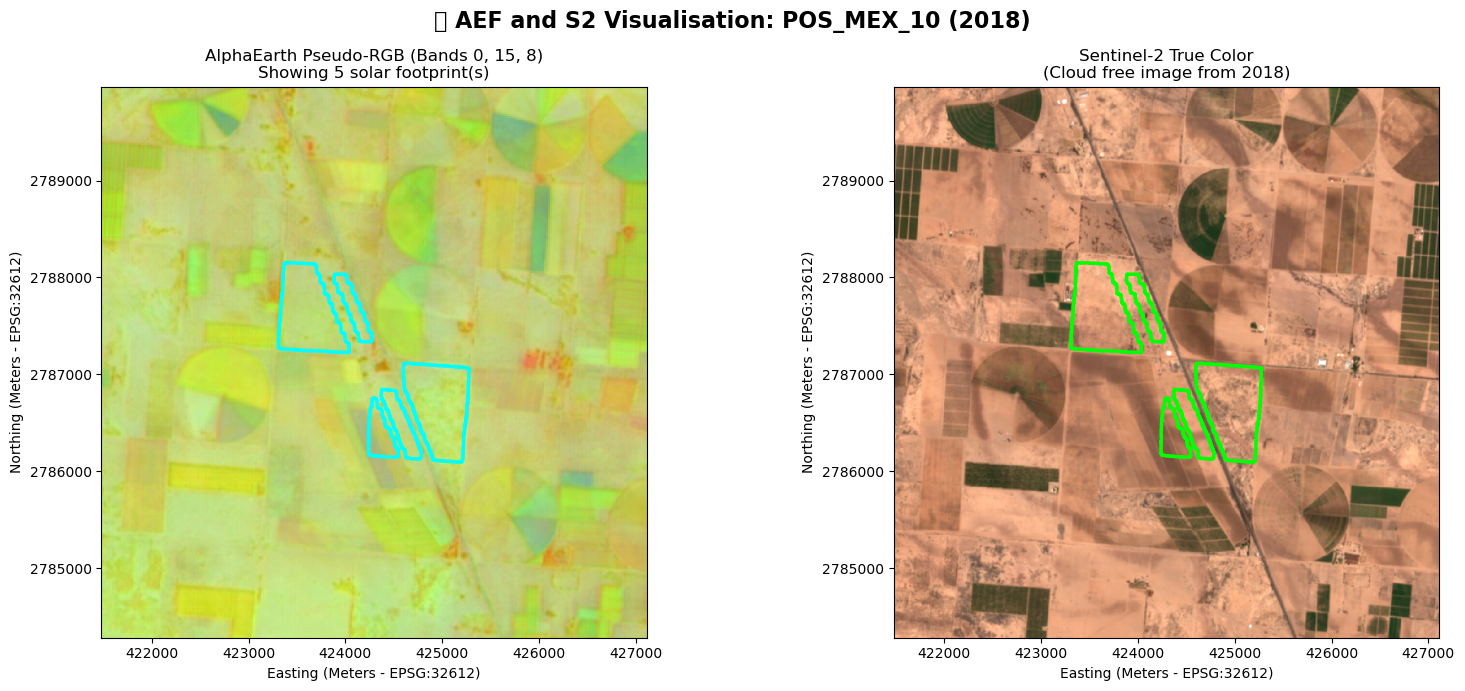

In [11]:
# ==========================================
# 1. DYNAMIC CONFIGURATION (Only change this!)
# ==========================================
raster_path = "POS_MEX_10_2018.tif" 

gpkg_file = "global_solar_ml_pipeline.gpkg"
export_layer = "base_train_export_ready"
base_layer = "base_train"

# Automatically extract the Cluster ID and Year from the filename
filename_no_ext = raster_path.replace('.tif', '')
# Split from the right side at the first underscore to perfectly isolate the year
cluster_id, year_str = filename_no_ext.rsplit('_', 1)
target_year = int(year_str)

print(f"🎯 Auto-Target Locked: {cluster_id} | Year: {target_year}")

# ==========================================
# 2. LOAD RASTER & SPATIAL GRIDS
# ==========================================
print("Opening AlphaEarth raster to anchor spatial extent...")
with rasterio.open(raster_path) as src:
    img_data = src.read()  
    raster_crs = src.crs
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    bbox_geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

# ==========================================
# 3. FETCH CONSTITUENT POLYGONS
# ==========================================
print(f"Fetching structural footprints for '{cluster_id}'...")
export_gdf = gpd.read_file(gpkg_file, layer=export_layer)
cluster_row = export_gdf[export_gdf['PV_ID'] == cluster_id].iloc[0]

raw_ids = cluster_row['original_site_ids']
constituent_ids = ast.literal_eval(raw_ids) if isinstance(raw_ids, str) else list(raw_ids)

base_gdf = gpd.read_file(gpkg_file, layer=base_layer)
individual_sites = base_gdf[base_gdf['PV_ID'].isin(constituent_ids)]

# Ensure vectors match the raster's metric layout exactly
if individual_sites.crs != raster_crs:
    individual_sites = individual_sites.to_crs(raster_crs)

# ==========================================
# 4. ALPHAEARTH NORMALIZATION
# ==========================================
print("Normalizing AlphaEarth embedding array (Pseudo-RGB)...")
img_display = img_data[[0, 15, 8], :, :].transpose(1, 2, 0)
img_min, img_max = np.nanmin(img_display), np.nanmax(img_display)
img_display = (img_display - img_min) / (img_max - img_min + 1e-8)

# ==========================================
# 5. LIGHTWEIGHT SENTINEL-2 STREAM (SEAMLESS MOSAIC)
# ==========================================
print("Streaming corresponding Sentinel-2 true-color composite via GEE REST API...")

bounds_4326 = gpd.GeoSeries([bbox_geom], crs=raster_crs).to_crs("EPSG:4326").total_bounds
ee_bounds = ee.Geometry.Rectangle(list(bounds_4326))

s2_collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")

# Filter for the year and bounds, and drop heavily clouded scenes
s2_match = (s2_collection
            .filterDate(f'{target_year}-01-01', f'{target_year}-12-31')
            .filterBounds(ee_bounds)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))) 

if s2_match.size().getInfo() == 0:
    print("⚠️ No clear Sentinel-2 imagery found for this exact box and year. Returning blank panel.")
    s2_img = np.zeros((512, 512, 3))
else:
    # THE FIX: Create a seamless median composite instead of a single clipped scene
    s2_composite = s2_match.median()
    
    thumb_url = s2_composite.visualize(bands=['B4', 'B3', 'B2'], min=0, max=3000).getThumbURL({
        'region': ee_bounds,
        'dimensions': 1024, 
        'format': 'png',
        'crs': str(raster_crs).upper() 
    })
    
    response = requests.get(thumb_url)
    s2_img = np.array(Image.open(BytesIO(response.content)))

# ==========================================
# 6. DASHBOARD DISPLAY
# ==========================================
print("Rendering dashboard layouts...")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"🛰️ AEF and S2 Visualisation: {cluster_id} ({target_year})", fontsize=16, fontweight='bold')

# --- PANEL 1: ALPHAEARTH OVERLAY ---
axes[0].imshow(img_display, extent=extent)
if not individual_sites.empty:
    individual_sites.plot(ax=axes[0], facecolor='none', edgecolor='cyan', linewidth=2.5)
axes[0].set_title(f"AlphaEarth Pseudo-RGB (Bands 0, 15, 8)\nShowing {len(individual_sites)} solar footprint(s)")

# --- PANEL 2: SENTINEL-2 OVERLAY ---
axes[1].imshow(s2_img, extent=extent)
if not individual_sites.empty:
    individual_sites.plot(ax=axes[1], facecolor='none', edgecolor='lime', linewidth=2.5)
axes[1].set_title(f"Sentinel-2 True Color\n(Cloud free image from {target_year})")

for ax in axes:
    ax.set_xlabel(f"Easting (Meters - {raster_crs})")
    ax.set_ylabel(f"Northing (Meters - {raster_crs})")
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

🎯 Auto-Target Locked: NEG_HUN_139 | Year: 2022
Opening AlphaEarth raster to anchor spatial extent...
Normalizing AlphaEarth embedding array (Pseudo-RGB)...
Streaming corresponding Sentinel-2 true-color composite via GEE REST API...
Rendering dashboard layouts...


/tmp/ipykernel_5654/4016673732.py:87: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/solar-siting-ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


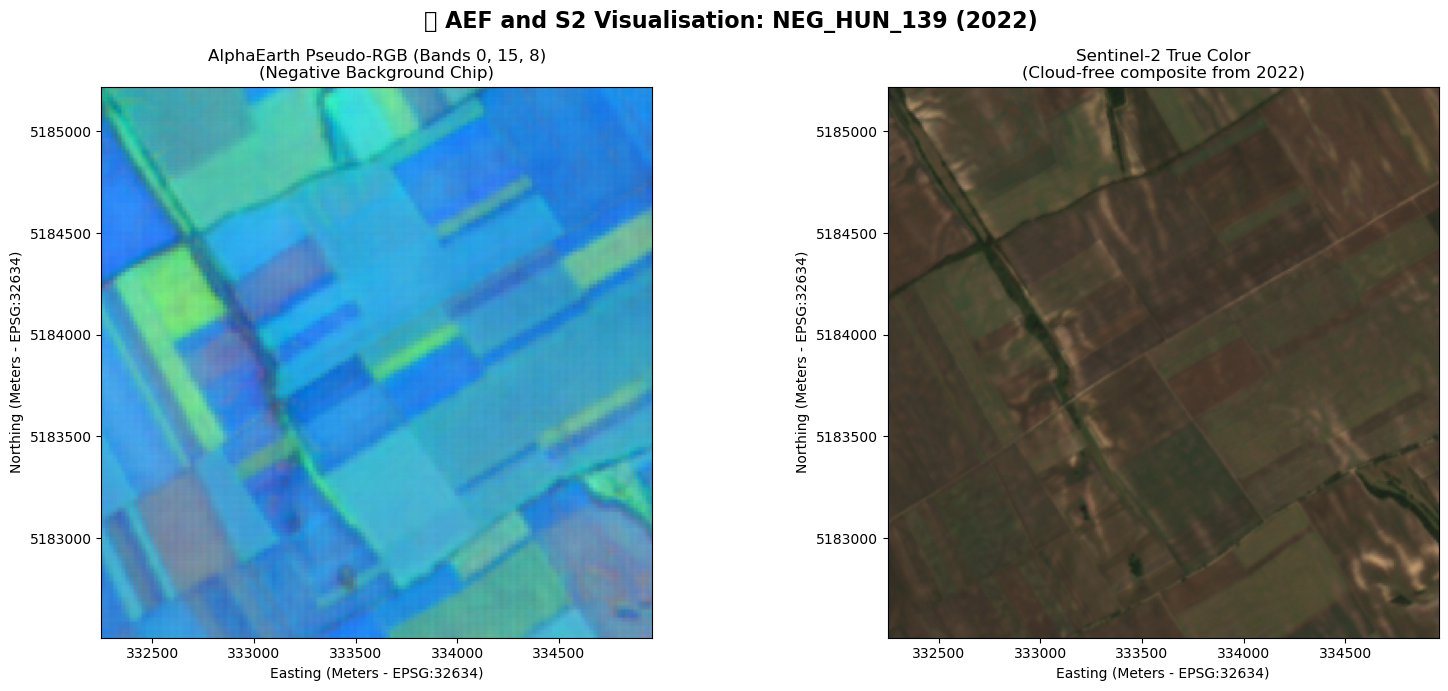

In [12]:
# ==========================================
# 1. DYNAMIC CONFIGURATION (Only change this!)
# ==========================================
# Change this to your negative chip filename
raster_path = "NEG_HUN_139_2022.tif" 

# Automatically extract the ID and Year from the filename
filename_no_ext = raster_path.replace('.tif', '')
chip_id, year_str = filename_no_ext.rsplit('_', 1)
target_year = int(year_str)

print(f"🎯 Auto-Target Locked: {chip_id} | Year: {target_year}")

# ==========================================
# 2. LOAD RASTER & SPATIAL GRIDS
# ==========================================
print("Opening AlphaEarth raster to anchor spatial extent...")
with rasterio.open(raster_path) as src:
    img_data = src.read()  
    raster_crs = src.crs
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    bbox_geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

# ==========================================
# 3. ALPHAEARTH NORMALIZATION
# ==========================================
print("Normalizing AlphaEarth embedding array (Pseudo-RGB)...")
img_display = img_data[[0, 15, 8], :, :].transpose(1, 2, 0)
img_min, img_max = np.nanmin(img_display), np.nanmax(img_display)
img_display = (img_display - img_min) / (img_max - img_min + 1e-8)

# ==========================================
# 4. LIGHTWEIGHT SENTINEL-2 STREAM (SEAMLESS MOSAIC)
# ==========================================
print("Streaming corresponding Sentinel-2 true-color composite via GEE REST API...")

# Translate the bounding box for the Earth Engine API query
bounds_4326 = gpd.GeoSeries([bbox_geom], crs=raster_crs).to_crs("EPSG:4326").total_bounds
ee_bounds = ee.Geometry.Rectangle(list(bounds_4326))

s2_collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")

# Filter for the year and bounds, and drop heavily clouded scenes
s2_match = (s2_collection
            .filterDate(f'{target_year}-01-01', f'{target_year}-12-31')
            .filterBounds(ee_bounds)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))) 

if s2_match.size().getInfo() == 0:
    print("⚠️ No clear Sentinel-2 imagery found for this exact box and year. Returning blank panel.")
    s2_img = np.zeros((512, 512, 3))
else:
    # Create a seamless median composite instead of a single clipped scene
    s2_composite = s2_match.median()
    
    thumb_url = s2_composite.visualize(bands=['B4', 'B3', 'B2'], min=0, max=3000).getThumbURL({
        'region': ee_bounds,
        'dimensions': 1024, 
        'format': 'png',
        'crs': str(raster_crs).upper() 
    })
    
    response = requests.get(thumb_url)
    s2_img = np.array(Image.open(BytesIO(response.content)))

# ==========================================
# 5. DASHBOARD DISPLAY
# ==========================================
print("Rendering dashboard layouts...")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"🛰️ AEF and S2 Visualisation: {chip_id} ({target_year})", fontsize=16, fontweight='bold')

# --- PANEL 1: ALPHAEARTH ---
axes[0].imshow(img_display, extent=extent)
axes[0].set_title("AlphaEarth Pseudo-RGB (Bands 0, 15, 8)\n(Negative Background Chip)")

# --- PANEL 2: SENTINEL-2 ---
axes[1].imshow(s2_img, extent=extent)
axes[1].set_title(f"Sentinel-2 True Color\n(Cloud-free composite from {target_year})")

for ax in axes:
    ax.set_xlabel(f"Easting (Meters - {raster_crs})")
    ax.set_ylabel(f"Northing (Meters - {raster_crs})")
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()